# **Project Name**    - Google PlayStore Reviews



##### **Project Type**    - Exploratory Data Analysis (EDA)
##### **Contribution**    - Individual
##### **Team Member 1**   - SAGAR JAIN


# **Project Summary -**

This project analyzes the Google Play Store dataset to identify key factors that influence app success in terms of installs, ratings, and user engagement. The analysis was performed on over 10,000 applications along with user review data.

The workflow included data cleaning (handling missing values, duplicates, and data type conversion), followed by exploratory data analysis using univariate, bivariate, and multivariate techniques. A correlation analysis was also conducted to understand relationships between numerical variables.

Key insights revealed that user engagement (reviews) is the strongest driver of installs, free apps significantly outperform paid apps, and category selection plays an important role in app popularity.

The insights from this analysis help developers and businesses make data-driven decisions to optimize pricing strategy, improve user experience, and enhance overall app growth.

# **GitHub Link -**

https://github.com/Sagarjain93/EDA_Google_Playstore_Reviews

# **Problem Statement**


*  The Google Play Store is one of the largest mobile app marketplaces, hosting thousands of applications across diverse categories.

*  Due to intense competition, developers and businesses need to understand the key factors that influence app success, such as installs, user ratings, and engagement levels.

*  This project analyzes Google Play Store data to identify patterns related to app categories, pricing strategy, size, user reviews, and sentiment, with the goal of uncovering insights that support data-driven decision-making for developers and businesses.

#### **Define Your Business Objective?**

*  The primary objective of this project is to analyze Google Play Store apps along with user review data to identify the factors that drive app popularity, user satisfaction, and overall performance.

*  The insights generated from this analysis can help stakeholders optimize app strategy, improve user experience, enhance engagement, and make informed decisions related to pricing, feature development, and market positioning.

# ***Let's Begin !***

## ***1. Know Your Data***

###  Import Libraries

In [56]:
# Import Libraries

#Data Manipulation Libraries
import pandas as pd
import numpy as np

#Data Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Date time libraries
import datetime as dt
from datetime import datetime

#Set consistant theme for plots
sns.set_theme(style='whitegrid')

### Dataset Loading

In [ ]:
# Clone GitHub repository
!git clone https://github.com/Sagarjain93/EDA_Google_Playstore_Reviews.git

# Move inside the project folder
%cd EDA_Google_Playstore_Reviews

Cloning into 'EDA_Google_Playstore_Reviews'...
remote: Enumerating objects: 83, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 83 (delta 36), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (83/83), 4.57 MiB | 7.38 MiB/s, done.
Resolving deltas: 100% (36/36), done.
/content/EDA_Google_Playstore_Reviews


In [20]:
df_play_store = pd.read_csv("raw_data/Play Store Data.csv")
df_user_review = pd.read_csv("raw_data/User Reviews Data.csv")

print("Loaded successfully!")

Loaded successfully!


### Dataset First View

In [ ]:
# View First few rows of Play_store_data
df_play_store.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [ ]:
# View First Few Rows Of User_review_data
df_user_review.head()

,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


###  Dataset Rows & Columns count

In [21]:
# Dataset Rows & Columns count
print (f" The shape of the Play store dataset is {df_play_store.shape}")
print(f" The Shape of the User Reviews data is {df_user_review.shape}")

 The shape of the Play store dataset is (10841, 13)
 The Shape of the User Reviews data is (64295, 5)


*  The Play Store dataset has 10841 rows and 16 columns.

*  The User Reviews dataset has 64295 rows and 5 columns.

### Dataset Information

In [22]:
# Play Store Dataset Info
df_play_store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [23]:
# User Review Dataset Info
df_user_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64295 entries, 0 to 64294
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   App                     64295 non-null  object 
 1   Translated_Review       37427 non-null  object 
 2   Sentiment               37432 non-null  object 
 3   Sentiment_Polarity      37432 non-null  float64
 4   Sentiment_Subjectivity  37432 non-null  float64
dtypes: float64(2), object(3)
memory usage: 2.5+ MB


#### Duplicate Values

In [24]:
# Play Store Dataset Duplicate Value Count
df_play_store.duplicated().sum()

np.int64(483)

In [25]:
# User Review Dataset Duplicate Value Count
df_user_review.duplicated().sum()

np.int64(33616)

#### Missing Values/Null Values

In [26]:
# Missing Values/Null Values Count in Play Store Dataset
df_play_store.isnull().sum()

,0
App,0
Category,0
Rating,1474
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [27]:
# Missing Values/Null Values Count in User Review Dataset
df_user_review.isnull().sum()

,0
App,0
Translated_Review,26868
Sentiment,26863
Sentiment_Polarity,26863
Sentiment_Subjectivity,26863


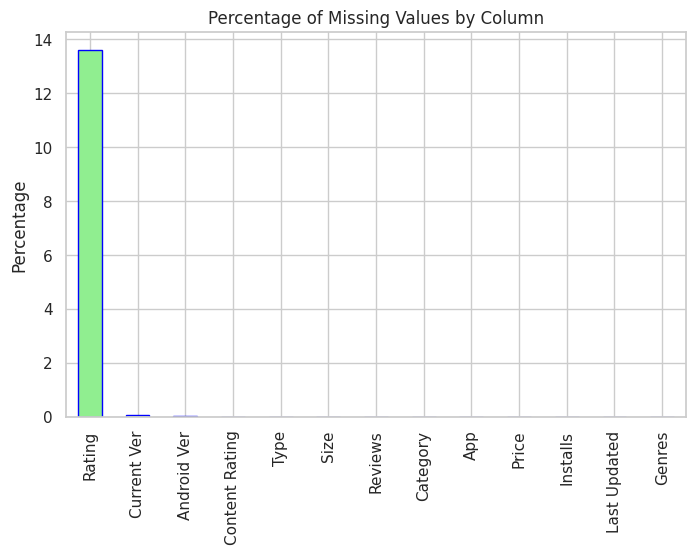

In [28]:
#  Visualizing the missing values in Play store data set
(df_play_store.isnull().sum() / len(df_play_store) * 100).sort_values(ascending=False).plot(
    kind='bar', figsize=(8,5), color='lightgreen', edgecolor='blue')
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.show()

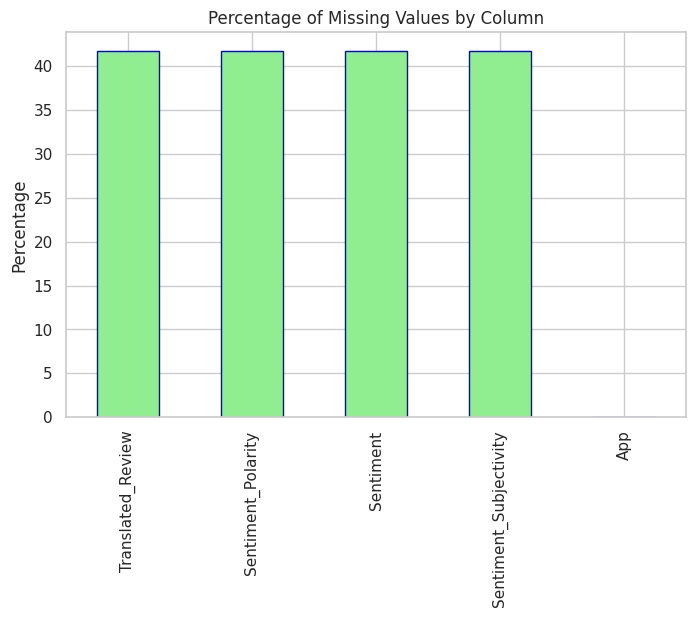

In [29]:
#  Visualizing the missing values in User Review data set
(df_user_review.isnull().sum() / len(df_user_review) * 100).sort_values(ascending=False).plot(
    kind='bar', figsize=(8,5), color='lightgreen', edgecolor='blue')
plt.title("Percentage of Missing Values by Column")
plt.ylabel("Percentage")
plt.xticks(rotation=90)
plt.show()

#### What did you know about your dataset?

**PLAY STORE DATA SET (df_play_store)**


**1. Dataset Size & Structure**

*  Rows: 10,841

*  Columns: 13

**2. Duplicates:483**

**3. Missing values:**

*  Rating → 1,474 missing

*  Type → 1 missing

*  Content Rating → 1 missing

*  Current Ver → 8 missing

*  Android Ver → 3 missing

**USER REVIEW DATASET (df_user_review)**

**1. Dataset Size and Structure**

*  Rows: 64,295

*  Columns: 5

**2.Duplicates: 33,616**

**3.Missing values:**

*  Translated_Review → 26,868 missing

*  Sentiment, Sentiment_Polarity, Sentiment_Subjectivity → each has 26,863 missing

**Key Observations Before Merging**

*  **Common Key:** Both datasets share the column App — this will be our join key.

*  **Duplicates:** We have a high duplicate ratio (Play Store ~4.5%, User Review ~52%).

*  **Nulls:** Especially in review text and sentiment columns; if merged, I’ll carry forward a lot of missing values.

*  **Data Type Issues:** Reviews, Installs, Price, Size are stored as object in df_play_store — need conversion before analysis.

**Dataset Size & Structure**

*  Rows: 10,841

*  Columns: 16 (12 from Play Store data + 3 aggregated sentiment metrics + 1 review count)







**Duplicate Records**

*  483 fully duplicated rows

Likely caused by:

*  Same app details appearing more than once in the Play Store dataset before merging.

Or multiple rows with identical values after aggregation.

**Missing Values**

*  Rating — 1,474 missing (some apps have no rating).

*  Type — 1 missing (likely data entry error).

*  Content Rating — 1 missing.

*  Current Ver — 8 missing.

*  Android Ver — 3 missing.

*  Aggregated Review Columns (Avg_Sentiment_Polarity, Avg_Sentiment_Subjectivity, Review_Count) — Missing in ~88% of rows because many apps had no reviews in the user review dataset.

**Column Types**

**Numeric**: Only 3 columns are numeric (Rating, Sentiment_Polarity, Sentiment_Subjectivity), all float64.

**Categorical/Object**: 14 columns including App, Category, Size, Installs, etc. Many may need cleaning (e.g., Price, Installs, Size stored as text).

**Potential Data Quality Issues**

*  Reviews, Size, Installs, and Price are stored as strings but may need numeric conversion after cleaning symbols/units.

*  Sentiment-related columns have high missingness — some analyses might need to exclude them.

*  Duplicates may be inflating statistics and skewing results.

## ***2. Understanding Your Variables***

### Dataset Columns

In [30]:
# Play Store Dataset Columns
df_play_store.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [31]:
# User Review DataSet Columns
df_user_review.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

### Dataset Describe

In [32]:
# Play Store Dataset Describe
df_play_store.describe().round()

,Rating
count,9367.0
mean,4.0
std,1.0
min,1.0
25%,4.0
50%,4.0
75%,4.0
max,19.0


In [33]:
# User Review Dataset Describe
df_user_review.describe().round()

,Sentiment_Polarity,Sentiment_Subjectivity
count,37432.0,37432.0
mean,0.0,0.0
std,0.0,0.0
min,-1.0,0.0
25%,0.0,0.0
50%,0.0,1.0
75%,0.0,1.0
max,1.0,1.0


### Variables Description

| Column                      | Description                                                                             |
| --------------------------- | --------------------------------------------------------------------------------------- |
| **App**                     | Name of the mobile application.                                                         |
| **Category**                | Category/genre of the app (e.g., Games, Education, Business).                           |
| **Rating**                  | Average user rating of the app (scale typically 1–5).                                   |
| **Reviews**                 | Number of user reviews submitted for the app.                                           |
| **Size**                    | Size of the app (e.g., “14M”, “Varies with device”).                                    |
| **Installs**                | Total number of times the app has been installed (string with symbols, e.g., “1,000+”). |
| **Type**                    | Indicates if the app is free or paid.                                                   |
| **Price**                   | Price of the app (e.g., “0” for free, “\$2.99” for paid).                               |
| **Content Rating**          | Age group suitability (e.g., “Everyone”, “Teen”).                                       |
| **Genres**                  | Additional genre classification (can have multiple genres separated by “;”).            |
| **Last Updated**            | Date when the app was last updated.                                                     |
| **Current Ver**             | Current version of the app.                                                             |
| **Android Ver**             | Minimum Android version required to run the app.                                        |
| **Translated\_Review**      | User review text (translated into a common language, typically English).                |
| **Sentiment**               | Sentiment category derived from the review (e.g., Positive, Negative, Neutral).         |
| **Sentiment\_Polarity**     | Sentiment polarity score (-1 = negative, 0 = neutral, +1 = positive).                   |
| **Sentiment\_Subjectivity** | Degree of subjectivity in the review (0 = factual, 1 = opinion-based).                  |


### Check Unique Values for each variable.

In [34]:
# Check Unique Values for each variable of Play Store Dataset
df_play_store.nunique()

,0
App,9660
Category,34
Rating,40
Reviews,6002
Size,462
Installs,22
Type,3
Price,93
Content Rating,6
Genres,120


In [ ]:
for col in df_play_store.columns:
    print(f"\nColumn: {col}")
    print(df_play_store[col].unique())



Column: App
['Photo Editor & Candy Camera & Grid & ScrapBook' 'Coloring book moana'
 'U Launcher Lite – FREE Live Cool Themes, Hide Apps' ...
 'Parkinson Exercices FR' 'The SCP Foundation DB fr nn5n'
 'iHoroscope - 2018 Daily Horoscope & Astrology']

Column: Category
['ART_AND_DESIGN' 'AUTO_AND_VEHICLES' 'BEAUTY' 'BOOKS_AND_REFERENCE'
 'BUSINESS' 'COMICS' 'COMMUNICATION' 'DATING' 'EDUCATION' 'ENTERTAINMENT'
 'EVENTS' 'FINANCE' 'FOOD_AND_DRINK' 'HEALTH_AND_FITNESS' 'HOUSE_AND_HOME'
 'LIBRARIES_AND_DEMO' 'LIFESTYLE' 'GAME' 'FAMILY' 'MEDICAL' 'SOCIAL'
 'SHOPPING' 'PHOTOGRAPHY' 'SPORTS' 'TRAVEL_AND_LOCAL' 'TOOLS'
 'PERSONALIZATION' 'PRODUCTIVITY' 'PARENTING' 'WEATHER' 'VIDEO_PLAYERS'
 'NEWS_AND_MAGAZINES' 'MAPS_AND_NAVIGATION' '1.9']

Column: Rating
[ 4.1  3.9  4.7  4.5  4.3  4.4  3.8  4.2  4.6  3.2  4.   nan  4.8  4.9
  3.6  3.7  3.3  3.4  3.5  3.1  5.   2.6  3.   1.9  2.5  2.8  2.7  1.
  2.9  2.3  2.2  1.7  2.   1.8  2.4  1.6  2.1  1.4  1.5  1.2 19. ]

Column: Reviews
['159' '967' '8751

In [ ]:
# Check Unique Values for each variable of User Review Dataset
df_user_review.nunique()

,0
App,1074
Translated_Review,27994
Sentiment,3
Sentiment_Polarity,5410
Sentiment_Subjectivity,4474


In [ ]:
for col in df_user_review.columns:
    print(f"\nColumn: {col}")
    print(df_user_review[col].unique())



Column: App
['10 Best Foods for You' '104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室' '11st' ...
 'Hotwire Hotel & Car Rental App' 'Housing-Real Estate & Property'
 'Houzz Interior Design Ideas']

Column: Translated_Review
['I like eat delicious food. That\'s I\'m cooking food myself, case "10 Best Foods" helps lot, also "Best Before (Shelf Life)"'
 'This help eating healthy exercise regular basis' nan ...
 'Dumb app, I wanted post property rent give option. Website work. Waste time space phone.'
 'I property business got link SMS happy performance still guys need raise bar guys Cheers'
 'Useless app, I searched flats kondapur, Hyderabad . None number reachable I know flats unavailable would keep posts active']

Column: Sentiment
['Positive' nan 'Neutral' 'Negative']

Column: Sentiment_Polarity
[ 1.          0.25               nan ... -0.52857143 -0.37777778
  0.17333333]

Column: Sentiment_Subjectivity
[0.53333333 0.28846154        nan ... 0.51145833 0.7172619  0.2594697 ]


##  ***3.Data Wrangling***

### **Data Cleaning And Preprocessing In Play_store Dataset And User_review Dataset**

####  **Remove Whitespaces & Standardize Names of all the Columns**

In [35]:
df_play_store.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [36]:
df_user_review.columns

Index(['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity',
       'Sentiment_Subjectivity'],
      dtype='object')

In [37]:
# Remove whitespace from all the columns
df_play_store.columns = df_play_store.columns.str.replace(' ', '_').str.lower()
df_user_review.columns = df_user_review.columns.str.replace(' ', '_').str.lower()

**Check**

In [ ]:
df_play_store.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver'],
      dtype='object')

In [ ]:
df_user_review.columns

Index(['app', 'translated_review', 'sentiment', 'sentiment_polarity',
       'sentiment_subjectivity'],
      dtype='object')

####  **Remove Duplicates**

In [ ]:
df_play_store.duplicated().sum()

np.int64(483)

In [ ]:
df_user_review.duplicated().sum()

np.int64(33616)

In [ ]:
# Remove exact duplicates
df_play_store.drop_duplicates(inplace=True)
df_user_review.drop_duplicates(inplace=True)

**Check**

In [ ]:
df_play_store.duplicated().sum()

np.int64(0)

In [ ]:
df_user_review.duplicated().sum()

np.int64(0)

#### **Cleaning And Converting Columns**

**Converting 'installs' columns from text to numeric and changing its datatype**

In [ ]:
df_play_store['installs'].dtypes

dtype('O')

In [ ]:
df_play_store['installs'] = (
    df_play_store['installs']
    .astype(str)                           # Ensure strings
    .str.replace(r'[^0-9]', '', regex=True) # Remove "+" and commas
    .replace('', np.nan)                    # Replace empty with NaN
    .astype(float)                          # Convert to numeric
    .astype('Int64')                         # Convert to integer (nullable)
)

**Check**

In [ ]:
df_play_store['installs']

,installs
0,10000
1,500000
2,5000000
3,50000000
4,100000
...,...
10836,5000
10837,100
10838,1000
10839,1000


**Exploring Unique App Genres**

In [ ]:
all_genres = set()

df_play_store['genres'].dropna().apply(lambda x: all_genres.update(x.split(';')))

print("Unique Genres:", all_genres)
print("Number of Unique Genres:", len(all_genres))

Unique Genres: {'Finance', 'Arcade', 'Puzzle', 'Business', 'House & Home', 'Role Playing', 'Medical', 'Word', 'Maps & Navigation', 'Education', 'Creativity', 'Parenting', 'Action & Adventure', 'Communication', 'Racing', 'Action', 'Dating', 'Adventure', 'Personalization', 'Auto & Vehicles', 'Simulation', 'Photography', 'Music', 'Shopping', 'Productivity', 'Comics', 'Brain Games', 'Art & Design', 'Pretend Play', 'Educational', 'February 11, 2018', 'Books & Reference', 'Trivia', 'Video Players & Editors', 'Libraries & Demo', 'Weather', 'Entertainment', 'Events', 'Social', 'Casual', 'Card', 'Tools', 'Sports', 'Music & Audio', 'Beauty', 'Food & Drink', 'Travel & Local', 'Lifestyle', 'Casino', 'Music & Video', 'Board', 'News & Magazines', 'Strategy', 'Health & Fitness'}
Number of Unique Genres: 54


**Cleaning and Converting Price Column**

In [ ]:
df_play_store['price']

,price
0,0
1,0
2,0
3,0
4,0
...,...
10836,0
10837,0
10838,0
10839,0


In [ ]:
df_play_store['price'] = (
    df_play_store['price']
    .astype(str)
    .str.replace(r'[^0-9]', '', regex=True)  # Remove "$", "₹", text
    .replace('', np.nan)
    .astype('Int64')
)

**Check**

In [ ]:
df_play_store['price']

,price
0,0
1,0
2,0
3,0
4,0
...,...
10836,0
10837,0
10838,0
10839,0


**Converting App Size to Numeric (MB)**

In [ ]:
df_play_store['size']

,size
0,19M
1,14M
2,8.7M
3,25M
4,2.8M
...,...
10836,53M
10837,3.6M
10838,9.5M
10839,Varies with device


In [ ]:
def size_to_mb(size):
    size = str(size).strip().upper()
    if 'M' in size:
        return float(size.replace('M', ''))
    elif 'K' in size:
        return float(size.replace('K', '')) / 1024  # KB → MB
    else:
        return np.nan  # For "Varies with device" or missing

df_play_store['size_mb'] = df_play_store['size'].apply(size_to_mb)

**Check**

In [ ]:
df_play_store['size_mb']

,size_mb
0,19.0
1,14.0
2,8.7
3,25.0
4,2.8
...,...
10836,53.0
10837,3.6
10838,9.5
10839,NaN


**Aggregating User Reviews to App-Level**

In [ ]:
df_user_review

,app,translated_review,sentiment,sentiment_polarity,sentiment_subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.000000,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.250000,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.400000,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.000000,0.300000
...,...,...,...,...,...
64223,Housing-Real Estate & Property,"If photos posted portal load, fit purpose. I'm...",Positive,0.225000,0.447222
64226,Housing-Real Estate & Property,"Dumb app, I wanted post property rent give opt...",Negative,-0.287500,0.250000
64227,Housing-Real Estate & Property,I property business got link SMS happy perform...,Positive,0.800000,1.000000
64230,Housing-Real Estate & Property,"Useless app, I searched flats kondapur, Hydera...",Negative,-0.316667,0.400000


In [45]:
# Count of sentiments per app
sent_counts = df_user_review.pivot_table(
    index='app',
    columns='sentiment',
    values='translated_review',
    aggfunc='count',
    fill_value=0
).reset_index()

# Average polarity/subjectivity per app
agg_stats = df_user_review.groupby('app').agg({
    'sentiment_polarity': ['mean'],
    'sentiment_subjectivity': ['mean']
}).reset_index()

# Flatten multi-level columns
agg_stats.columns = ['app'] + ['_'.join(col).strip() for col in agg_stats.columns[1:]]

# Merge counts + stats
reviews_agg = sent_counts.merge(agg_stats, on='app', how='left')

In [ ]:
reviews_agg

,app,Negative,Neutral,Positive,sentiment_polarity_mean,sentiment_subjectivity_mean
0,10 Best Foods for You,5,11,79,0.465906,0.493254
1,104 找工作 - 找工作 找打工 找兼職 履歷健檢 履歷診療室,1,8,27,0.358227,0.508907
2,11st,7,9,23,0.181294,0.443957
3,1800 Contacts - Lens Store,3,5,32,0.318145,0.591098
4,1LINE – One Line with One Touch,8,3,27,0.196290,0.557315
...,...,...,...,...,...,...
860,Hotels.com: Book Hotel Rooms & Find Vacation D...,12,5,22,0.098559,0.525508
861,Hotspot Shield Free VPN Proxy & Wi-Fi Security,3,14,15,0.223750,0.380365
862,Hotstar,14,4,14,0.038178,0.493964
863,Hotwire Hotel & Car Rental App,6,11,16,0.187029,0.459717


**Changing Datatype of 'last_updated' to datetime datatype**

In [46]:
df_play_store['last_updated'] = pd.to_datetime(df_play_store['last_updated'], errors='coerce')

**Removing Outlier From Rating Column**

The Rating column has one outlier where rating is 19.0 having 1 count

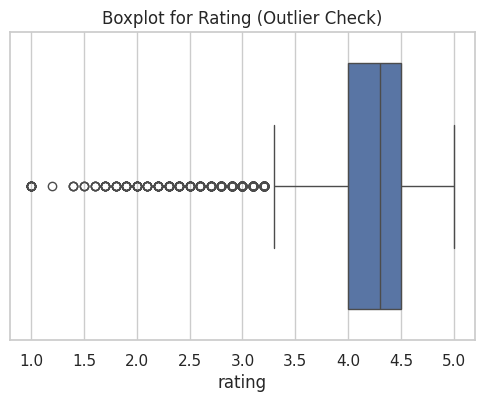

In [48]:
# Boxplot for rating column
plt.figure(figsize=(6,4))
sns.boxplot(x=df_play_store['rating'])
plt.title("Boxplot for Rating (Outlier Check)")
plt.show()

In [49]:
df_play_store['rating'].value_counts()

,count
rating,
4.4,1109
4.3,1076
4.5,1038
4.2,952
4.6,823
4.1,708
4.0,568
4.7,499
3.9,386


In [50]:
# Drop rows where rating = 19
df_play_store = df_play_store[df_play_store['rating'] != 19.0]

# Check again
print("\nUnique Rating values after:")
print(df_play_store['rating'].unique())


Unique Rating values after:
[4.1 3.9 4.7 4.5 4.3 4.4 3.8 4.2 4.6 3.2 4.  nan 4.8 4.9 3.6 3.7 3.3 3.4
 3.5 3.1 5.  2.6 3.  1.9 2.5 2.8 2.7 1.  2.9 2.3 2.2 1.7 2.  1.8 2.4 1.6
 2.1 1.4 1.5 1.2]


### **Merging The Two Datasets**


In [51]:
# merging the play_store and reviews_agg dataset
df_merged = df_play_store.merge(reviews_agg, on='app', how='left')

#### **View First Few Rows Of The Merged Dataset**

In [52]:
# few first few columns
df_merged.head()

,app,category,rating,reviews,size,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,Negative,Neutral,Positive,sentiment_polarity_mean,sentiment_subjectivity_mean
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,NaN,NaN,NaN,NaN,NaN
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,2018-01-15,2.0.0,4.0.3 and up,14.0,4.0,26.0,0.152652,0.64154
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,2018-08-01,1.2.4,4.0.3 and up,NaN,NaN,NaN,NaN,NaN
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,2018-06-08,Varies with device,4.2 and up,NaN,NaN,NaN,NaN,NaN
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,2018-06-20,1.1,4.4 and up,NaN,NaN,NaN,NaN,NaN


#### **Merged Dataset Shape,Size and Columns**

In [ ]:
df_merged.shape

(10357, 19)

In [ ]:
df_merged.size

196783

In [ ]:
df_merged.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver', 'size_mb', 'Negative', 'Neutral', 'Positive',
       'sentiment_polarity_mean', 'sentiment_subjectivity_mean'],
      dtype='object')

#### **Merged Dataset Info And Describe**

In [ ]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10357 entries, 0 to 10356
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   app                          10357 non-null  object        
 1   category                     10357 non-null  object        
 2   rating                       8892 non-null   float64       
 3   reviews                      10357 non-null  object        
 4   size                         10357 non-null  object        
 5   installs                     10357 non-null  Int64         
 6   type                         10356 non-null  object        
 7   price                        10357 non-null  Int64         
 8   content_rating               10357 non-null  object        
 9   genres                       10357 non-null  object        
 10  last_updated                 10357 non-null  datetime64[ns]
 11  current_ver                  10349 non-nu

In [ ]:
df_merged.describe().round(2)

,rating,installs,price,last_updated,size_mb,Negative,Neutral,Positive,sentiment_polarity_mean,sentiment_subjectivity_mean
count,8892.00,10357.0,10357.0,10357,8831.00,1079.00,1079.00,1079.00,1079.00,1079.00
mean,4.19,14157759.44,103.08,2017-11-14 09:25:19.320266496,21.29,8.95,4.69,23.81,0.19,0.49
min,1.00,0.0,0.0,2010-05-21 00:00:00,0.01,0.00,0.00,0.00,-0.50,0.00
25%,4.00,1000.0,0.0,2017-09-03 00:00:00,4.70,3.00,1.00,15.00,0.07,0.46
50%,4.30,100000.0,0.0,2018-05-20 00:00:00,13.00,6.00,4.00,22.00,0.18,0.50
75%,4.50,1000000.0,0.0,2018-07-19 00:00:00,29.00,11.50,7.00,28.00,0.29,0.54
max,5.00,1000000000.0,40000.0,2018-08-08 00:00:00,100.00,59.00,35.00,91.00,1.00,0.92
std,0.52,80239553.87,1627.86,NaN,22.54,10.04,4.35,15.19,0.16,0.08


#### **Checking and Handling Null Values In Merged Dataset**

In [ ]:
#checking null values in the new merged dataset
df_merged.isnull().sum()

,0
app,0
category,0
rating,1465
reviews,0
size,0
installs,0
type,1
price,0
content_rating,0
genres,0


**Handling Missing Values in Review Metrics**

In [ ]:
# removing null values in the various review columns
review_cols = ['Negative', 'Neutral', 'Positive', 'sentiment_polarity_mean', 'sentiment_subjectivity_mean']
df_merged[review_cols] = df_merged[review_cols].fillna(0)

In [ ]:
df_merged['reviews'] = (
    df_merged['reviews']
    .astype(str)                 # Ensure it’s string for cleaning
    .str.replace(r'[^0-9]', '', regex=True)  # Remove any non-numeric characters (commas, symbols)
    .replace('', np.nan)         # Empty strings → NaN
    .astype('Int64')             # Nullable integer
)

**Filling Nulls in Rating, Installs, Price, and Size**

In [ ]:
# filling the null values in 'rating','installs','price','size_mb' with their medians
for col in ['rating', 'installs', 'price', 'size_mb']:
    df_merged[col] = df_merged[col].fillna(df_merged[col].median())

**Handling Type, Content Rating, Current Version, and Android Version**

In [ ]:
cat_cols = ['type', 'content_rating', 'current_ver', 'android_ver']
for col in cat_cols:
    df_merged[col] = df_merged[col].fillna(df_merged[col].mode()[0])

In [ ]:
# Standardize "Varies with device" or similar typos
df_merged['current_ver'] = df_merged['current_ver'].replace(
    ['Varies with device', 'caried with devices', 'Varies with Devices'],
    np.nan
)

In [ ]:
df_merged['current_ver'] = df_merged['current_ver'].fillna(df_merged['current_ver'].mode()[0])

**Dropping Size and size_MB columns**

In [ ]:
df_merged.columns

Index(['app', 'category', 'rating', 'reviews', 'size', 'installs', 'type',
       'price', 'content_rating', 'genres', 'last_updated', 'current_ver',
       'android_ver', 'size_mb', 'Negative', 'Neutral', 'Positive',
       'sentiment_polarity_mean', 'sentiment_subjectivity_mean'],
      dtype='object')

In [ ]:
df_merged = df_merged.drop(columns=['size'])

**Handling Missing Values in Last Updated Column**

In [ ]:
df_merged['last_updated'] = df_merged['last_updated'].fillna(df_merged['last_updated'].median())

#### **Identify Numerical Columns and Categorical Columns**

In [ ]:
num_cols = [
    'rating',                   # app rating
    'reviews',                  # number of reviews
    'installs',                 # number of installs
    'price',                    # price of the app
    'size_mb',                  # size in MB
    'Negative',                 # negative review count
    'Neutral',                  # neutral review count
    'Positive',                 # positive review count
    'sentiment_polarity_mean',  # average polarity of reviews
    'sentiment_subjectivity_mean'  # average subjectivity of reviews
]

In [ ]:
cat_cols = [
    'app',                # app name
    'category',           # app category
    'type',               # Free / Paid
    'content_rating',     # Everyone, Teen, etc.
    'genres',             # app genres (could be multiple)
    'last_updated',       # datetime (could also be treated separately)
    'current_ver',        # current version
    'android_ver'         # minimum Android version
]

In [ ]:
print(f"Following are the numerical colums :\n{num_cols}\n")
print(f"Following are the categorical colums :\n{cat_cols}")

Following are the numerical colums :
['rating', 'reviews', 'installs', 'price', 'size_mb', 'Negative', 'Neutral', 'Positive', 'sentiment_polarity_mean', 'sentiment_subjectivity_mean']

Following are the categorical colums :
['app', 'category', 'type', 'content_rating', 'genres', 'last_updated', 'current_ver', 'android_ver']


### **What all manipulations have you done and insights you found?**

#### **Play Store Dataset (df_play_store) Cleaning**



*  Column name standardization

     Replaced spaces with underscores for all column names (e.g., Content Rating to content_rating).

*  String cleaning

      Stripped leading/trailing spaces from string columns like App.

*  Duplicate removal

    Removed exact duplicate rows using drop_duplicates().

*  Handling Rating column

    Identified invalid values (like ratings > 5) and corrected/removed if necessary.

    Cleaning numeric-like text columns

    Installs: Removed + and commas, converted to integer.

    Price: Removed $, ₹, converted to integer.

    Size: Converted "22M"/"340K" to MB using a function, stored as size_mb.

*  Handling categorical columns

    Columns like Type, Content_Rating, Current_Ver, Android_Ver prepared for missing values.

*  Datetime conversion

    Converted Last_Updated to datetime64[ns].

*  Handling missing values

    Numeric columns (rating, installs, price, size_mb) → filled with median.

    Categorical columns → filled with mode.

    Last_Updated → filled with median date.

*  Dropped unnecessary or duplicate columns

    Dropped original size and duplicate size_MB columns.

*  Review counts and sentiment aggregation preparation

    Prepared Play Store dataset to merge with aggregated user review data later.

#### **User Review Dataset (df_user_review) Cleaning**



*  String cleaning

    Stripped leading/trailing spaces from App.

*  Duplicate removal

    Removed exact duplicate review rows.

*  Handling missing values

    Columns like Translated_Review, Sentiment, Sentiment_Polarity, Sentiment_Subjectivity had missing values; handled later during aggregation.

*  Aggregating to app-level

    Counted number of Negative, Neutral, Positive reviews per app using a pivot table.

    Calculated average Sentiment_Polarity and Sentiment_Subjectivity per app.

    Flattened multi-level columns and merged counts + averages → reviews_agg.

#### **Merging Play Store and User Review Data**



*  Merge operation

    Merged df_play_store and reviews_agg on App using a left join to preserve all apps from Play Store.

*  Handling missing review values

    Apps with no reviews → filled Negative, Neutral, Positive, sentiment_polarity_mean, sentiment_subjectivity_mean with 0.

#### **Final Cleaning of Merged Dataset (df_merged)**

*  **Numeric columns**

    reviews, installs, price → converted to integers (Int64).

    size_mb → float.

    rating → float.

    Review metrics

    Negative, Neutral, Positive → converted to integer (Int64).

    sentiment_polarity_mean, sentiment_subjectivity_mean → kept as float.

*  **Categorical columns**

    Filled missing values in type, content_rating, current_ver, android_ver with mode.

    Cleaned current_ver values like "Varies with device" → NaN → filled with mode.

*  **Datetime column**

    last_updated → filled missing values with median date.

*  **Column deduplication**

    Removed duplicate size_MB/size_mb columns.

*  **Result**

    Dataset now has one row per app, with cleaned Play Store info and aggregated review metrics.

  

**Outcome:**

df_merged is a clean, analysis-ready dataset with 10358 apps and 18 columns, fully prepared for:

*  EDA (plots, distributions, correlations)

*  Statistical analysis

*  Further ML modeling can be done (e.g., predicting ratings, installs, or app success metrics)

## ***4.Hypothesis/Assumptions***

*Based on business understanding, the following hypotheses are tested during the analysis:*

* Apps with higher ratings tend to have more installs.

*  Free apps receive more installs than paid apps.

*  Apps with a higher number of reviews are more popular.

*  Positive user sentiment is associated with higher app ratings.

*  Certain categories (e.g., Games, Family) have higher installs than others.

*  Lower-priced apps have higher user adoption.

*  Larger app size may negatively impact installs due to storage concerns.

*EDA and statistical analysis are performed to validate or reject these assumptions.*

## ***5. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **Univariate Analysis**

#### Chart - 1 Frequency Of Top 15 Apps

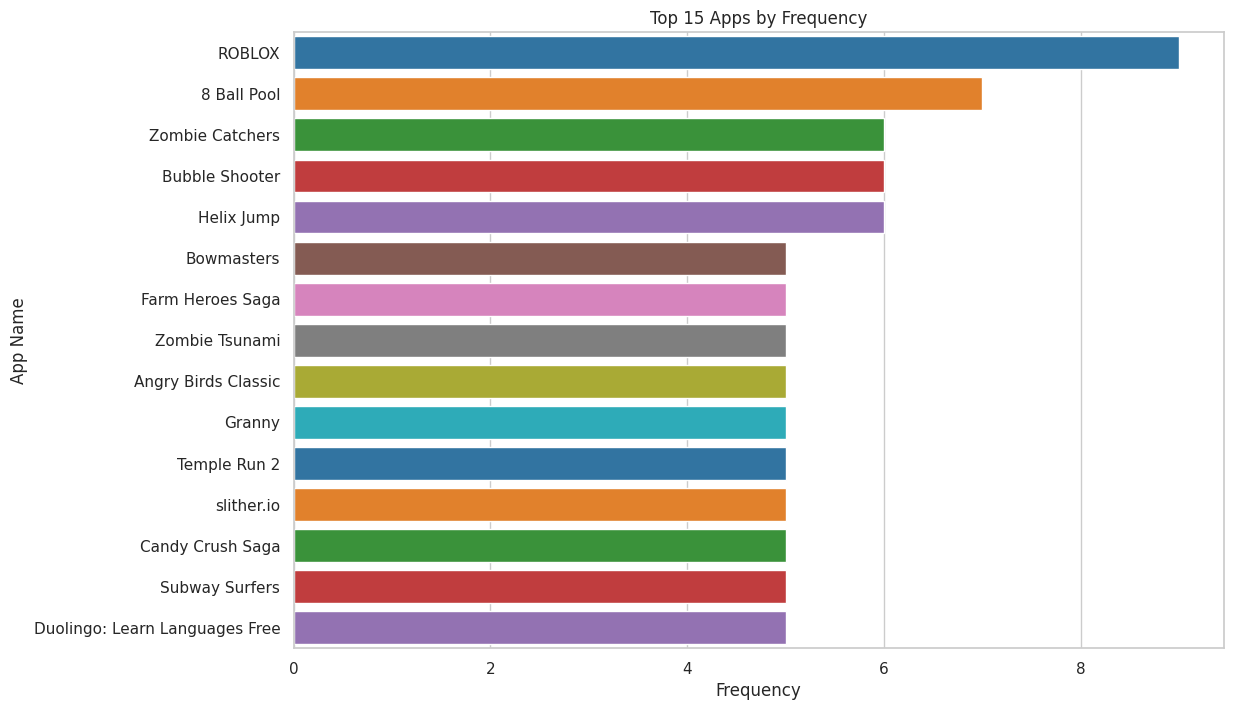

In [ ]:
# Chart - 1 visualization code

#frequency count
app_counts = df_merged['app'].value_counts()

#visulaization of the app_counts
plt.figure(figsize=(12,8))
sns.barplot(x=app_counts.head(15).values,
            y=app_counts.head(15).index,
            palette=sns.color_palette("tab10",15),
            legend=False,
            hue=app_counts.head(15).index
            )
plt.xlabel('Frequency')
plt.ylabel('App Name')
# plt.xticks(rotation = 90)
plt.title('Top 15 Apps by Frequency')
plt.show()

##### 1. Why did you pick the specific chart?

The **horizontal bar chart** is chosen because it is ideal for visualizing and comparing categorical data—here, app names—by frequency. It clearly displays the top 15 apps ranked by how often they appear, making it easy to identify leading items at a glance.

##### 2. What is/are the insight(s) found from the chart?

*  **ROBLOX** is the most frequently mentioned app, indicating it is highly popular or favored among users in the dataset.

*  Most other apps (from **8 Ball Pool down to Duolingo**) have a fairly equal frequency (**mostly 5 or 6**), suggesting these apps are similarly popular.

*  The list is dominated by games, with only **Duolingo** being non-gaming, showing a strong preference or demand for mobile gaming apps among the target audience.Answer Here

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  **Product prioritization:** Knowing which apps are most popular allows businesses to tailor partnerships, promotional efforts, or advertising investments toward these apps for maximum ROI.

*  **User acquisition strategies:** Focusing on game-related content or features is likely to resonate well with this audience, potentially boosting engagement and growth.

*  **Diversification opportunities:** Seeing Duolingo among mostly games suggests that there's room for educational or non-gaming apps to grow and diversify the portfolio.

**Insights that may lead to NEGATIVE GROWTH**

*  The dominance of similar types of apps (mostly games) may indicate market saturation or lack of diversity.

*  Only one non-game app (Duolingo) is prominent, meaning other non-gaming segments might be underrepresented or neglected,

#### Chart - 2 Frequency Of Top 15 Category

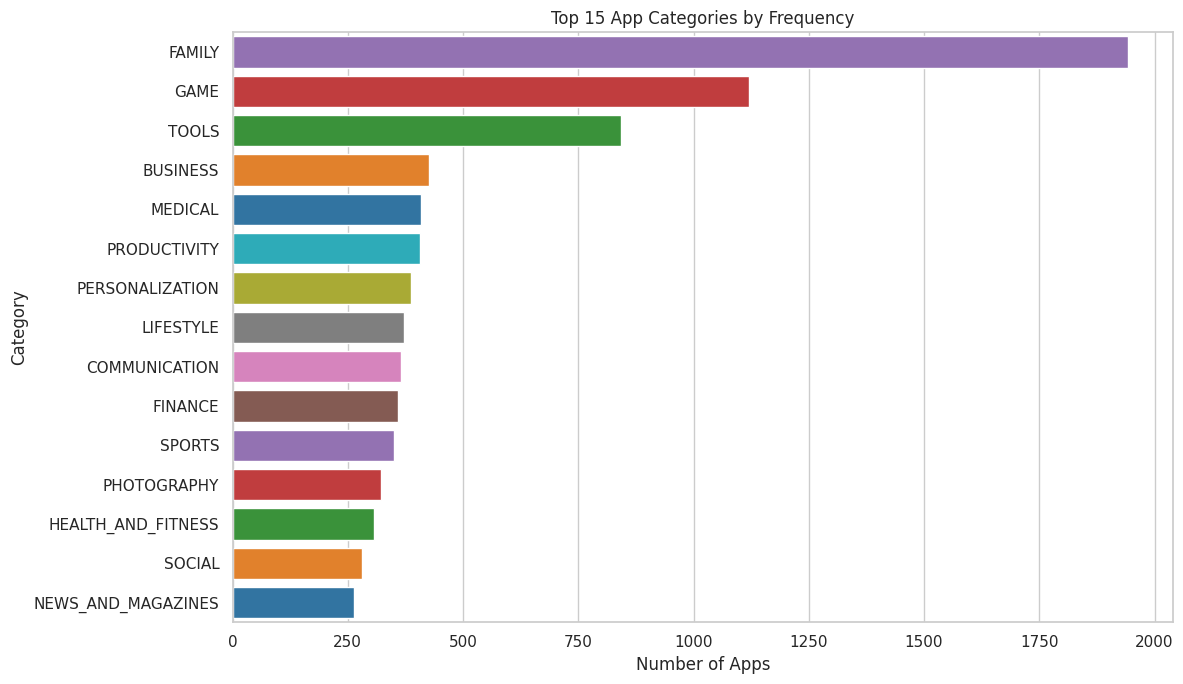

In [ ]:
# Chart - 2 visualization code
top15_categories = df_merged['category'].value_counts().nlargest(15)

plt.figure(figsize=(12,7))
sns.barplot(y=top15_categories.index,
            x=top15_categories.values,
            palette=sns.color_palette("tab10",15),
            hue =top15_categories,
            legend = False)
plt.title('Top 15 App Categories by Frequency')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The **horizontal bar chart** effectively shows the distribution of app categories by frequency. It offers a straightforward comparison across many categories, making it easy to spot the most common app types in the Google Play Store dataset.

##### 2. What is/are the insight(s) found from the chart?

*  The **FAMILY** category has the highest number of apps, far exceeding all others.

*  **GAME** and **TOOLS** categories also have a significant presence.

*  Categories like **MEDICAL,PRODUCTIVITY,** and **PERSONALIZATION** are moderately represented, while others like **HEALTH_AND_FITNESS** and **NEWS_AND_MAGAZINES** have fewer apps.

*  This suggests a user and developer focus on family-oriented apps and games.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**
*   Businesses can focus on the highly populated **FAMILY** and **GAME** categories for development or advertising to tap into larger market segments. It also highlights potential opportunities for app innovation in less saturated categories.

**Negative:**
*   Heavy dominance of certain categories could imply intense competition, making it harder for new entrants to stand out in those crowded categories, potentially leading to negative growth if not differentiated well. Also, some niche categories might struggle due to fewer apps and possibly less user interest.

#### Chart - 3 Frequency Of Top 15 App Genres

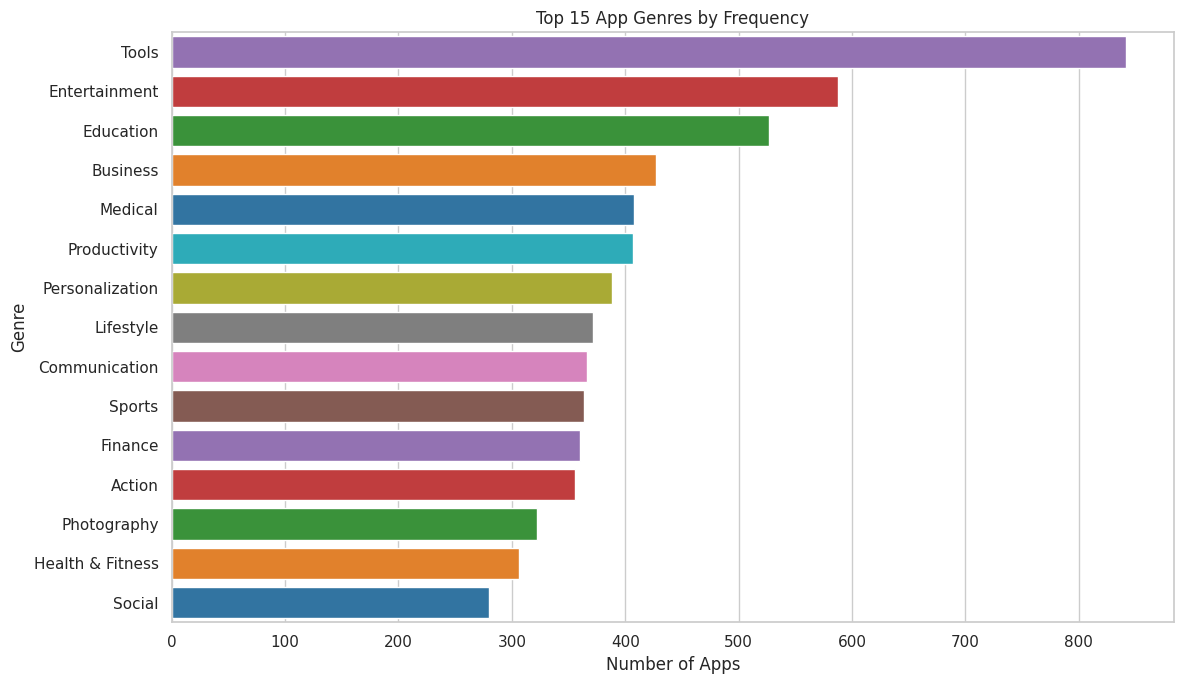

In [ ]:
# Chart - 3 visualization code
top15_genres = df_merged['genres'].value_counts().nlargest(15)

plt.figure(figsize=(12,7))
sns.barplot(y=top15_genres.index,
            x=top15_genres.values,
            palette=sns.color_palette('tab10',15),
            hue = top15_genres.values,
            legend=False,)
plt.title('Top 15 App Genres by Frequency')
plt.xlabel('Number of Apps')
plt.ylabel('Genre')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The horizontal bar chart was selected to clearly show the distribution of app genres by frequency. It makes it easy to compare the popularity of different genres visually while accommodating long genre names without clutter.



##### 2. What is/are the insight(s) found from the chart?

*  **Tools** and **Entertainment** genres have the highest number of apps, indicating strong developer and user interest.

* **Education** and **Business** also have large presence, showing relevance beyond just entertainment apps.

*  Genres like **Action,Photography** and **Health & Fitness** attract moderate attention, while **Social** has the fewest apps among the top 15.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**
*   Helps identify thriving genres where businesses can invest or promote products, such as tools and entertainment apps with large audiences. Also highlights opportunities in growing genres like education.

**Negative:**
*   The concentration in a few genres may indicate high competition, making it challenging for newcomers to gain visibility unless they offer distinct features. Genres with fewer apps might face difficulty attracting user attention or may represent niche markets with limited growth.

#### Chart - 4 Distribution Of App Size

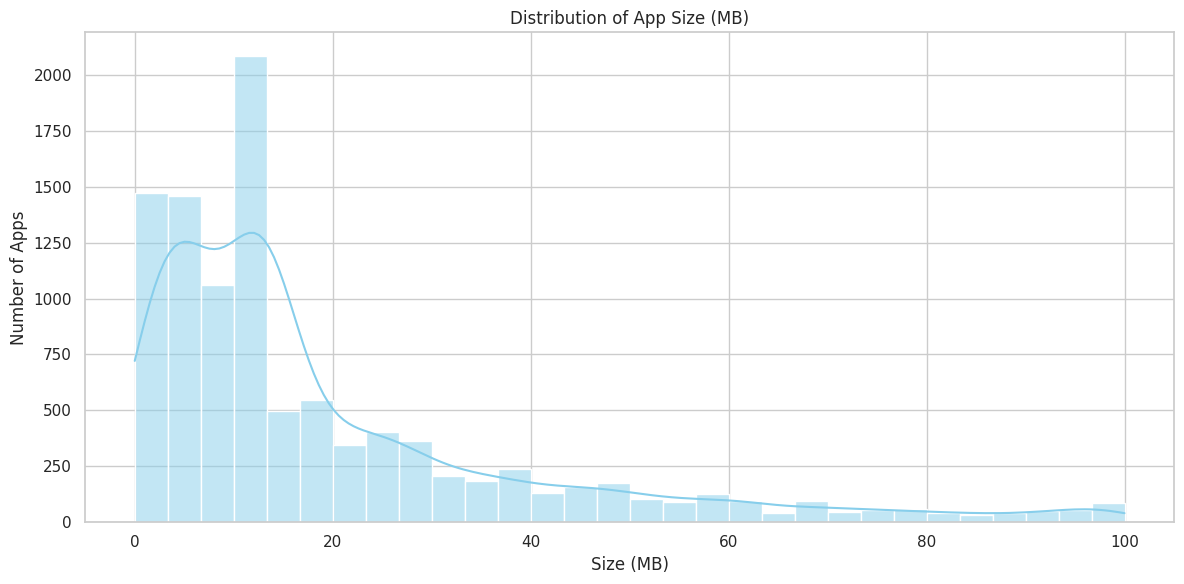

In [ ]:
# Chart - 4 visualization code

plt.figure(figsize=(12,6))
sns.histplot(df_merged['size_mb'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of App Size (MB)')
plt.xlabel('Size (MB)')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The histogram with KDE is chosen to visualize the distribution of a continuous numeric variable, app size in megabytes. It helps observe the frequency of different size ranges and the overall shape of the distribution, including skewness and modality.

##### 2. What is/are the insight(s) found from the chart?

*  Most apps have a relatively small size, with a large concentration around lower size values varying from 1 Mb to 15 Mb

*  The distribution is right-skewed, indicating some apps have much larger sizes but are less frequent.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**
*   Understanding app size distribution helps in optimizing resources and targeting app size limits for better user adoption, especially in regions with limited bandwidth or storage.

**Negative:**
*   Very large apps could face challenges with user downloads and installations, potentially limiting growth among users with older or low-storage devices. This could reduce the potential user base for those large apps.

#### Chart - 5 Count of Type Of Apps Downloaded (Free vs Paid)

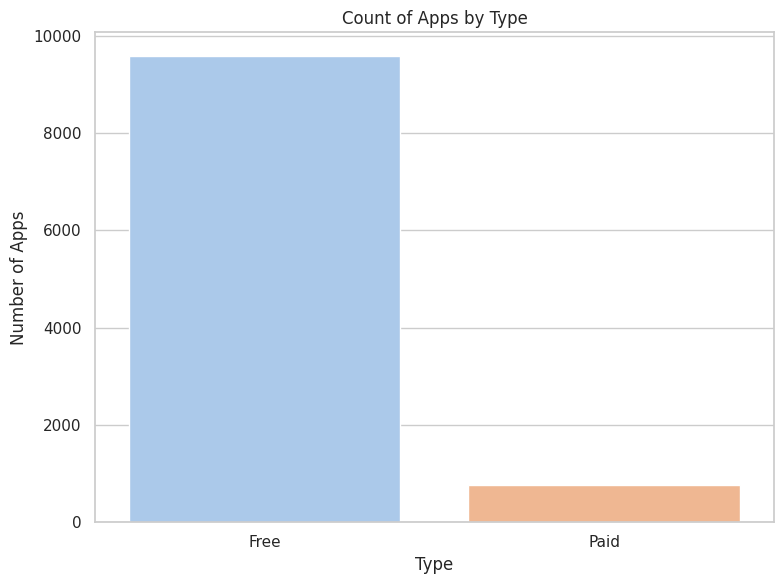

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(data=df_merged, x='type', hue='type', palette='pastel', legend=False)
plt.title('Count of Apps by Type')
plt.xlabel('Type')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()


##### 1. Why did you pick the specific chart?

The countplot is a natural choice for visualizing categorical data like the "type" column. It displays the frequency distribution of categories (e.g., Free vs. Paid apps) clearly, making it easy to compare the relative counts.

##### 2. What is/are the insight(s) found from the chart?

*  The chart shows the exact number of apps in each category .

*  It reveals a dominance of **Free** apps compared to paid ones.

* **Free** apps are almost 95000 ,while **Paid** apps are around 500.

*  Provides a straightforward understanding of how app types are distributed in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**
 *  Knowing the distribution of app types helps businesses strategize monetization models, marketing, and development priorities (e.g., focus on free apps with ads or paid premium apps).

**Negative:**
*   Over-reliance on one app type (e.g., mostly free apps) could indicate challenges in generating direct revenue from paid downloads, signaling a need to diversify revenue streams or improve paid app value propositions.

#### Chart - 6 Distribution of Apps By Content Rating

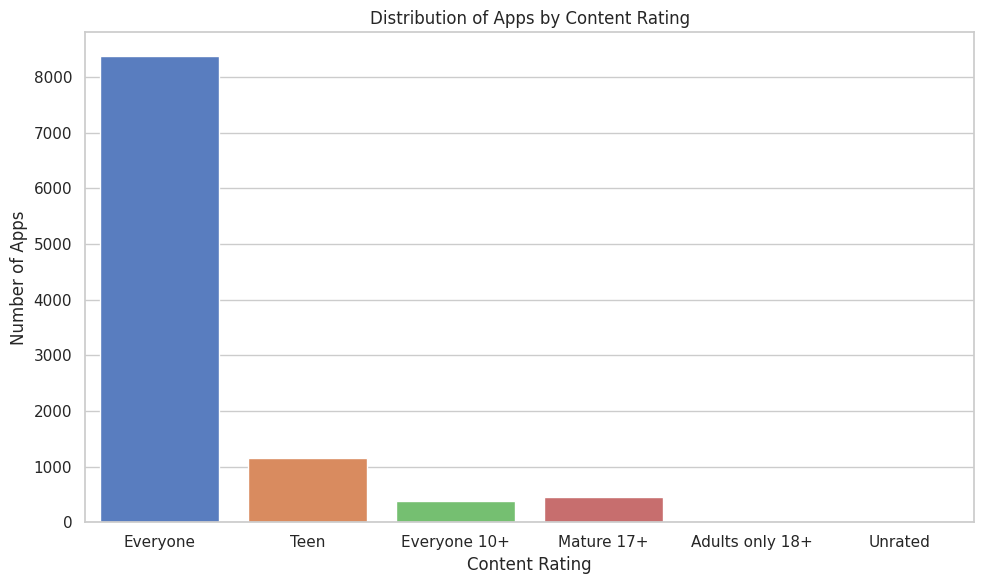

In [ ]:
# Chart - 6 visualization code
plt.figure(figsize=(10,6))
sns.countplot(x='content_rating', data=df_merged,hue = 'content_rating',legend=False, palette='muted')
plt.title('Distribution of Apps by Content Rating')
plt.xlabel('Content Rating')
plt.ylabel('Number of Apps')
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

The countplot is chosen because **content_rating** is a categorical variable. This chart provides a clear visual of the distribution and frequency of apps across different content ratings, making it easy to compare categories.

##### 2. What is/are the insight(s) found from the chart?

*  The chart reveals **Everyone** content ratings is the most common among the apps, followed by **Teen.**

*  It may show fewer apps in restrictive or mature content categories, indicating market focus or regulatory impact.

*  Helps understand the audience segmentation based on content suitability.



##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive:**
*   Enables businesses to tailor marketing, app development, and compliance strategies aligned with the most common content ratings to maximize reach and regulatory adherence.

**Negative:**
*   Apps categorized under stringent content ratings may have limited audience and growth potential. This can restrict revenue opportunities and necessitates careful content and compliance management.

In [ ]:
df_merged.head(1)

,app,category,rating,reviews,installs,type,price,content_rating,genres,last_updated,current_ver,android_ver,size_mb,Negative,Neutral,Positive,sentiment_polarity_mean,sentiment_subjectivity_mean
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,10000,Free,0,Everyone,Art & Design,2018-01-07,1.0.0,4.0.3 and up,19.0,0.0,0.0,0.0,0.0,0.0


### **Bivariate Analysis**

#### **Categorical Vs Categorical**

#### Chart - 7 Category Vs Type (Which categories are Free/Paid?)

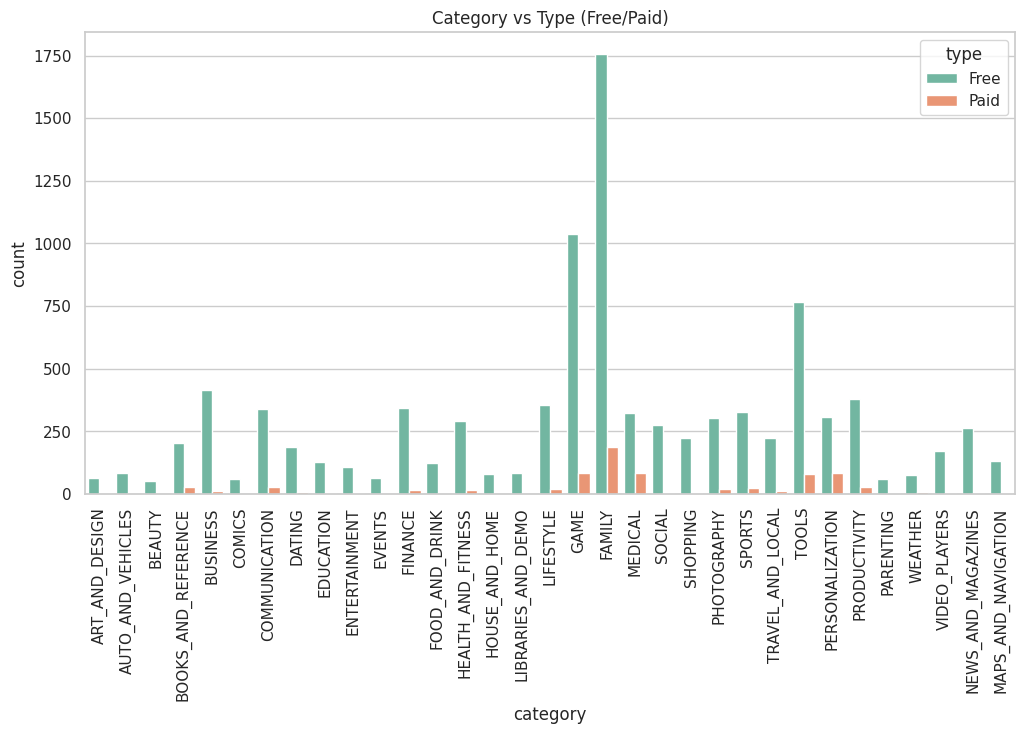

In [ ]:
# Chart - 7 visualization code
plt.figure(figsize=(12,6))
sns.countplot(data=df_merged, x="category", hue="type", palette="Set2")
plt.xticks(rotation=90)
plt.title("Category vs Type (Free/Paid)")
plt.show()


##### 1. Why did you pick the specific chart?

Countplot is ideal to compare counts of apps split by free/paid across categories.

##### 2. What is/are the insight(s) found from the chart?

*  Most categories are dominated by free apps.

*  A few categories like **Family,Game ,Medical,Personalization** have more paid apps compared to other category.

* **Family,Games,Tools,Productivity,Business** have large no. free apps

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
*   Helps businesses decide which category has more willingness to pay (opportunity for paid app development).

**Negative Growth Insight:**
*   If a category has very few paid apps but low installs overall, introducing paid apps in that space may not succeed.

#### Chart - 8 Category Vs Content Rating

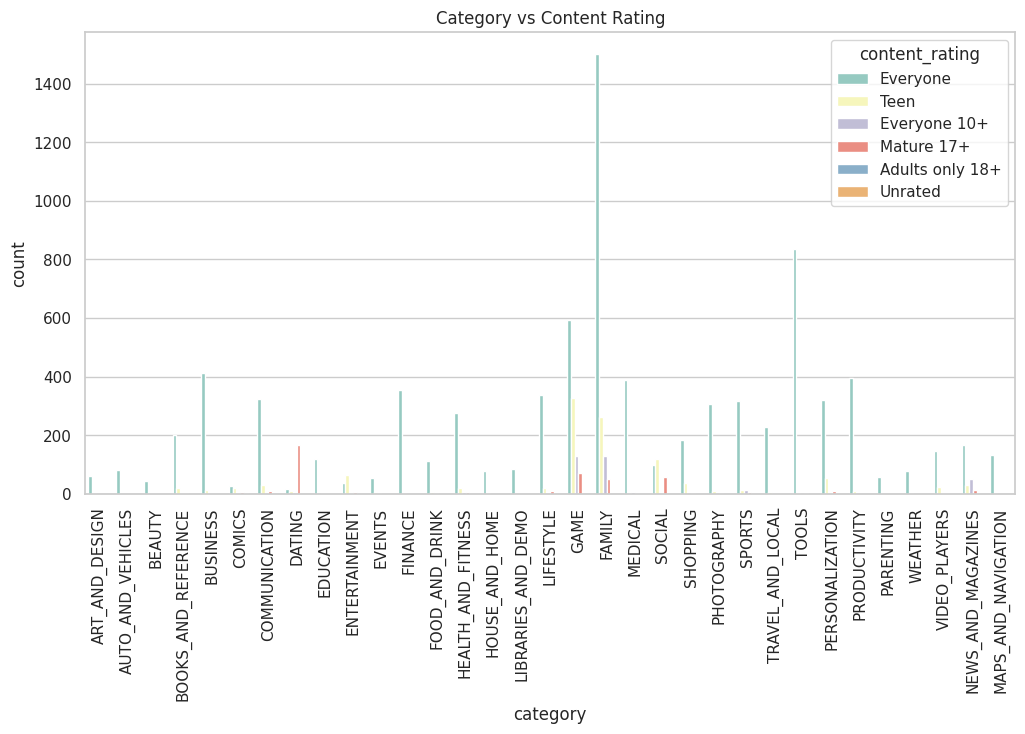

In [ ]:
# Chart - 8 visualization code
plt.figure(figsize=(12,6))
sns.countplot(data=df_merged, x="category", hue="content_rating", palette="Set3")
plt.xticks(rotation=90)
plt.title("Category vs Content Rating")
plt.show()


##### 1. Why did you pick the specific chart?

To see which categories are designed for which age group.

##### 2. What is/are the insight(s) found from the chart?

*  Most categories are focused on **Everyone.**

*  **Games,Family,Communication** often skew towards **Teen.**

*  **Dating,Social,Game** has **Mature 17+**

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
*  Companies can target content according to the right audience segment.

**Negative Growth Insight:**

*  If categories like “Education” have fewer apps for kids, missing out on children’s segment could hurt growth.

#### Chart - 9 Type Vs Content Rating

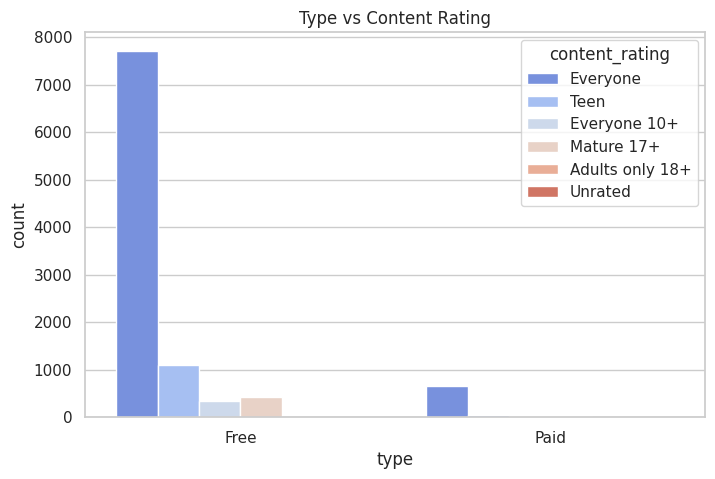

In [ ]:
# Chart - 9 visualization code
plt.figure(figsize=(8,5))
sns.countplot(data=df_merged, x="type", hue="content_rating", palette="coolwarm")
plt.title("Type vs Content Rating")
plt.show()

##### 1. Why did you pick the specific chart?

Simple way to compare Paid vs Free apps by audience group.

##### 2. What is/are the insight(s) found from the chart?

*  **Free apps** dominate across all content ratings


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:**
*  Businesses know free apps attract wider age ranges, while paid apps are viable in niche mature markets.

**Negative Growth Insight:**
*  If free apps already saturate a category, launching more free apps there may struggle to gain visibility.

#### **Categorical Vs Numerical**

#### Chart - 10 Category Vs Rating

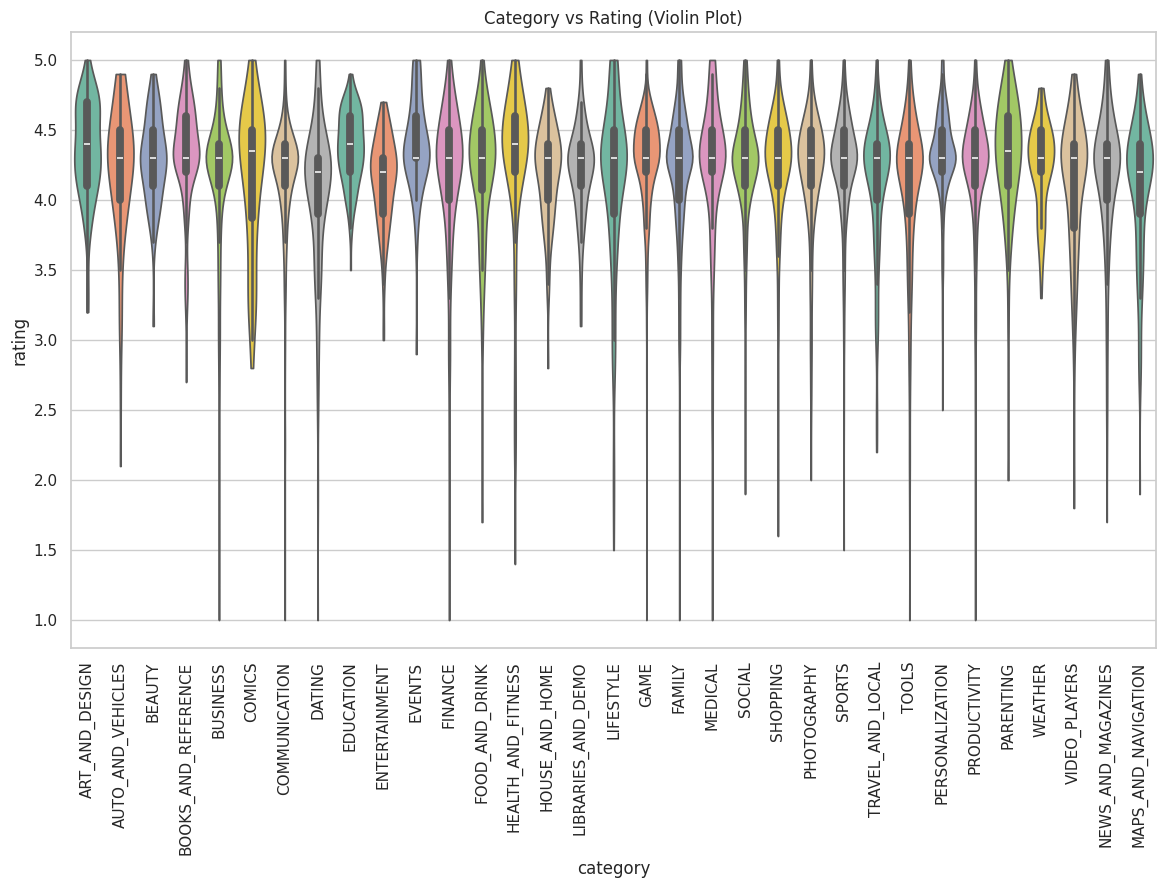

In [ ]:
# Chart - 10 visualization code
plt.figure(figsize=(14,8))
sns.violinplot(
    data=df_merged,
    x="category",
    y="rating",
    hue="category",
    legend=False,
    palette="Set2",
    cut=0
)
plt.xticks(rotation=90)
plt.title("Category vs Rating (Violin Plot)")
plt.show()


##### 1. Why did you pick the specific chart?

I chose the violin plot because it not only summarizes ratings (like a boxplot) but also shows the distribution density. This helps us see if ratings are skewed (e.g., concentrated at 5) or spread out (e.g., many mixed reviews).

##### 2. What is/are the insight(s) found from the chart?

*  Some categories **(e.g., GAME, FAMILY, TOOLS,MEDICAL,PRODUCTIVITY,TOOL,DATING,COMMUNICATION,BUSINESS)** have wide spreads, showing mixed user experiences.

*  Others (e.g., EDUCATION, BEAUTY & WEATHER) show ratings clustered at the higher end, suggesting more consistent quality.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Insights**
*   By identifying categories with consistently high ratings, developers and businesses can focus resources on those categories.

*  Categories with wide variation can be investigated further — maybe they have sub-genres where some apps succeed and others fail.

**Negative Inights**

*  Categories where ratings are skewed low or highly inconsistent may suffer from user dissatisfaction (e.g., buggy apps, poor updates).

*  For example, if TOOLS or GAME shows both very high and very low ratings, it signals quality inconsistency — which can lead to negative reviews, churn, and uninstall rates.

#### Chart - 11 Category Vs Installs

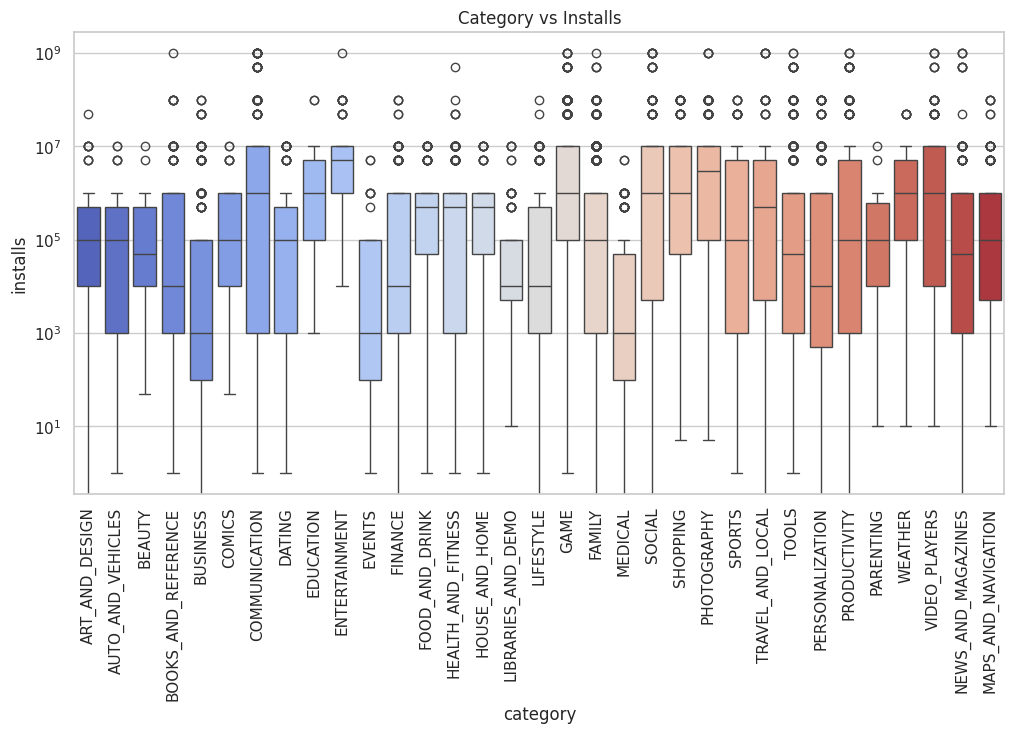

In [ ]:
# Chart - 11 visualization code
plt.figure(figsize=(12,6))
sns.boxplot(data=df_merged, x="category", y="installs",hue= 'category',legend=False, palette="coolwarm")
plt.xticks(rotation=90)
plt.yscale("log")  # installs vary widely, so log scale helps
plt.title("Category vs Installs")
plt.show()


##### 1. Why did you pick the specific chart?

*  A boxplot is great for showing the distribution of installs across app categories.

*  It captures median, quartiles, and outliers, helping us see which categories have consistently high installs vs. which ones are spread out.

*  Since installs vary by orders of magnitude, the log scale was used to make comparisons meaningful.


##### 2. What is/are the insight(s) found from the chart?

*  Categories like **GAME, COMMUNICATION, TOOLS, SOCIAL, and VIDEO PLAYERS** have very high install counts (many outliers touching 10⁸–10⁹).

*  Niche categories like **BEAUTY, EVENTS, PARENTING** show much lower installs overall.

*  Most categories have a wide distribution (apps with both very low and very high installs), but some are tightly clustered (like **BEAUTY, LIBRARIES & DEMO**).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Insight**

*   Categories such as **GAME, COMMUNICATION, SOCIAL, and VIDEO PLAYERS** attract massive user bases → good investment areas.

*  Shopping and Tools also show strong installs, suggesting stable demand and higher user adoption.

**Negative Growth Insight:**

*  Categories like **BEAUTY, PARENTING, and EVENTS** show low and limited installs → lower market penetration.

*  These may not yield high returns unless targeted to very niche audiences.

*  High competition in categories like GAME may also be a risk, since while installs are high, user retention and monetization could be harder.

#### Chart - 12 Type Vs Rating

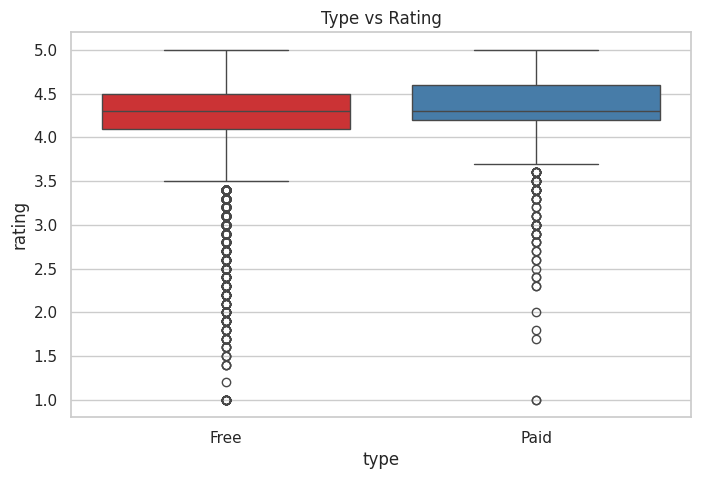

In [ ]:
# Chart - 12 visualization code

plt.figure(figsize=(8,5))
sns.boxplot(data=df_merged, x="type", y="rating",hue = "type",legend=False, palette="Set1")
plt.title("Type vs Rating")
plt.show()

##### 1. Why did you pick the specific chart?

To compare ratings between **Free vs Paid apps** and see if payment type impacts user perception.

##### 2. What is/are the insight(s) found from the chart?

*  **Paid apps** generally have slightly higher median ratings.

*  **Free apps** show more variability and many low-rating outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*  Paid apps maintaining higher ratings indicate that users value quality when they pay → scope for premium products.

**Negative Growth Insight:**
*  Free apps suffer from inconsistent quality, with many outliers dragging ratings down → risk of poor user retention.

#### Chart - 13 Type Vs Installs

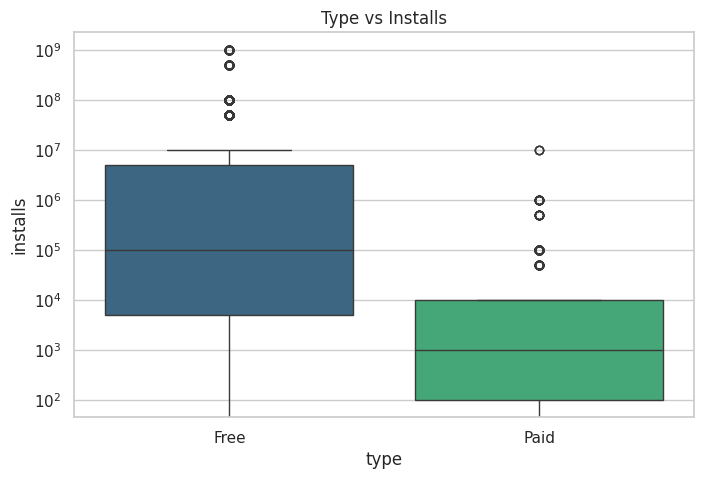

In [ ]:
# Chart - 13 visualization code
plt.figure(figsize=(8,5))
sns.boxplot(data=df_merged, x="type", y="installs",hue = 'type',legend=False,palette="viridis")
plt.yscale("log")
plt.title("Type vs Installs")
plt.show()


##### 1. Why did you pick the specific chart?

To see install differences between free and paid apps.

##### 2. What is/are the insight(s) found from the chart?

*  **Free apps** have significantly higher installs, with extreme outliers in the millions and billions.

*  **Paid apps** show very limited installs, clustered at much lower values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*  **Free apps** drive massive reach and user base, making them great for ads and brand awareness.

**Negative Growth Insight:**
*  **Paid apps** face low adoption barriers due to cost, restricting market penetration.

#### Chart-14 Content Rating Vs Rating

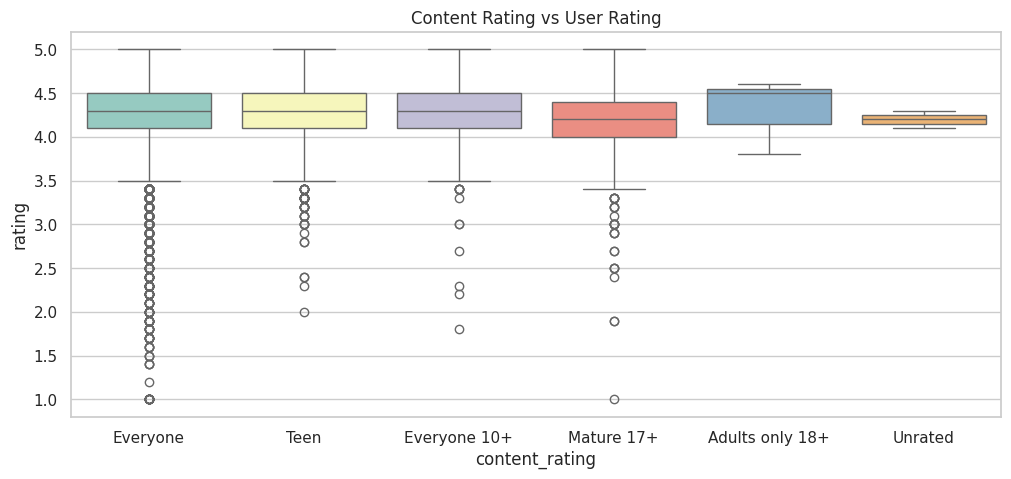

In [ ]:
# Chart - 14 visualization code
plt.figure(figsize=(12,5))
sns.boxplot(data=df_merged, x="content_rating", y="rating",hue = 'content_rating',legend=False, palette="Set3")
plt.title("Content Rating vs User Rating")
plt.show()


##### 1. Why did you pick the specific chart?

To check if audience group affects app ratings.

##### 2. What is/are the insight(s) found from the chart?

*  Most content categories maintain high median ratings (≈4.2–4.4).

*  **Everyone** and **Teen** have the widest spread with more outliers (lower ratings).

*  **Adults only 18+** and **Unrated** categories are more consistent with fewer outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**
*  Apps across all categories maintain strong ratings, meaning content variety does not drastically reduce user satisfaction.

**Negative Growth Insight:**
*  High number of low-rating outliers in **Everyone** & **Teen** categories may signal quality issues in mass-market apps.

#### Chart - 15 Content Rating Vs Installs

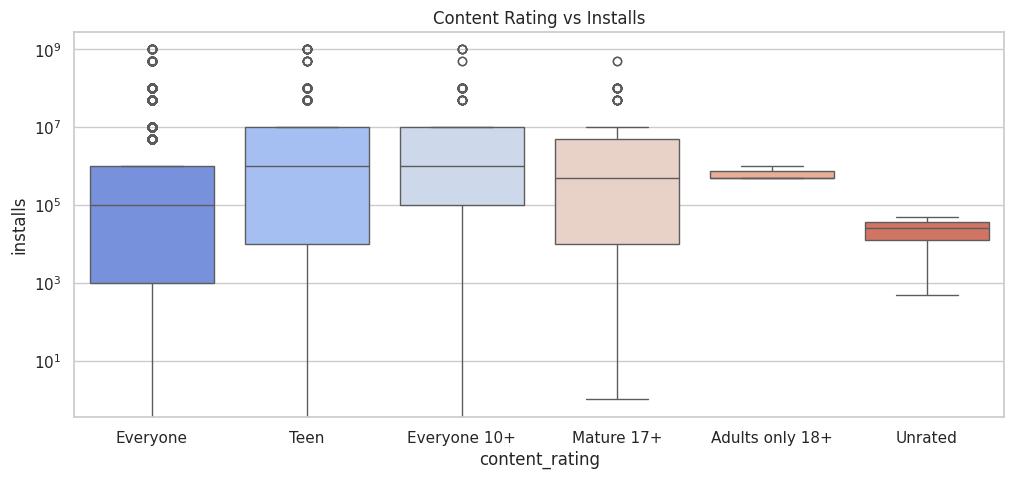

In [ ]:
# Chart - 15 visualization code
plt.figure(figsize=(12,5))
sns.boxplot(data=df_merged, x="content_rating", y="installs",hue="content_rating",legend=False, palette="coolwarm")
plt.yscale("log")
plt.title("Content Rating vs Installs")
plt.show()

##### 1. Why did you pick the specific chart?

To measure popularity (installs) by age group.

##### 2. What is/are the insight(s) found from the chart?

*  Apps rated **Everyone** and **Teen** have the highest number of installs with a very wide distribution (including apps crossing 10⁸–10⁹ installs).

*  **Everyone 10+** and **Mature 17+** also show strong installs, but slightly lower than **Everyone** and **Teen**.

*  **Adults only 18+** and **Unrated** categories have much fewer installs, concentrated at lower scales.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Impact:**

*  The huge install base for **Everyone** and **Teen** categories highlights a strong mass-market adoption, making them ideal for revenue generation (ads, in-app purchases).

**Negative Growth Insight:**

*  Categories like **Adults only 18+** and **Unrated** are struggling with installs, which may indicate limited audience reach, lower demand, or stricter regulations, leading to slower growth.

#### **Numerical Vs Numerical**

#### Chart - 16 Price Vs Installs

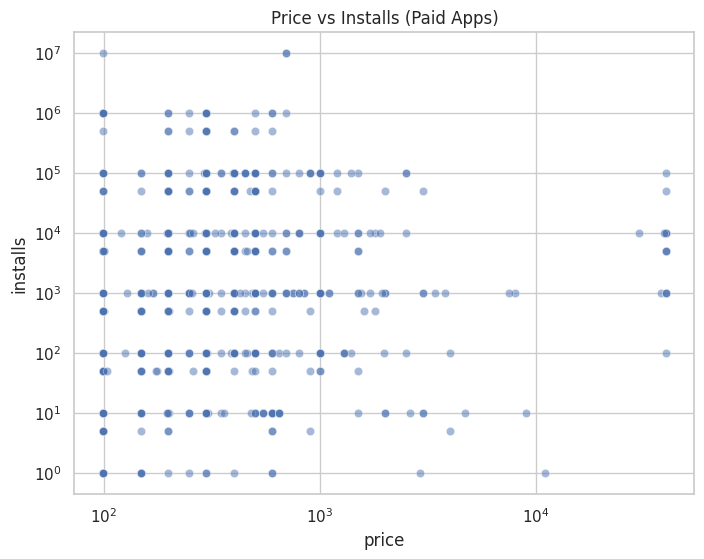

In [ ]:
# Chart - 16 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merged[df_merged['price']>0], x="price", y="installs", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.title("Price vs Installs (Paid Apps)")
plt.show()



##### 1. Why did you pick the specific chart?

A scatter plot with log-log scaling was chosen to capture the relationship between app price and installs. Since both price and installs vary widely (from free/low-cost apps to very expensive niche apps, and from a few installs to millions), logarithmic scaling helps in visualizing the spread and trends more clearly.

##### 2. What is/are the insight(s) found from the chart?

*  Most apps, even when priced higher, tend to have fewer installs.

*  Paid apps priced in the lower range (₹100–₹500) still see more downloads compared to apps priced extremely high.

*  A few outliers exist where higher-priced apps have managed to gain decent installs, but they are rare.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  Businesses can use this insight to design effective pricing strategies. The data shows that lower-priced apps attract more installs, which suggests that affordable pricing helps reach a wider audience.

*  For niche or premium apps, the insights help in identifying the balance between price and expected installs, which can guide revenue optimization.

**Negative Insights:**

*  Apps with very high prices (above ₹5,000) tend to struggle with installs.

*  This indicates that pricing too aggressively without providing sufficient value may discourage potential users, leading to negative growth in user adoption.

#### Chart - 17 App Size Vs Install

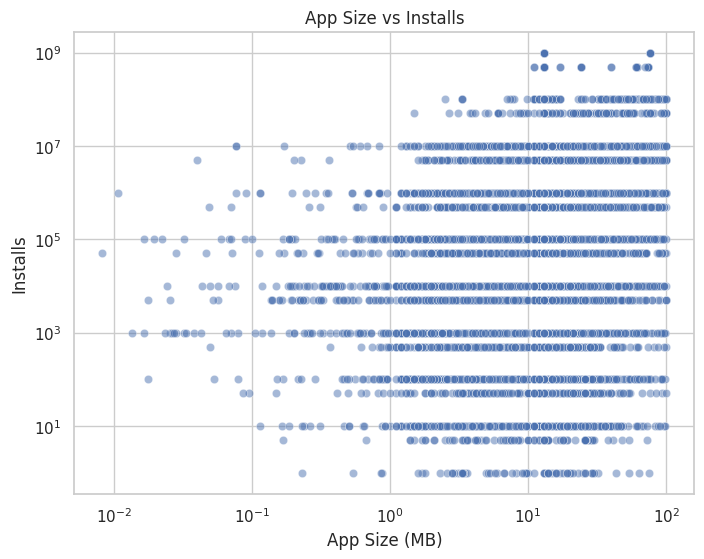

In [ ]:
# Chart - 17 visualization code
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_merged, x="size_mb", y="installs", alpha=0.5)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("App Size (MB)")
plt.ylabel("Installs")
plt.title("App Size vs Installs")
plt.show()


##### 1. Why did you pick the specific chart?

A scatter plot is ideal for showing the relationship between two continuous variables—here, app size (MB) and installs. Using logarithmic axes for both variables makes it easier to observe patterns and correlations across wide-ranging values, highlighting both dense clusters and outliers.

##### 2. What is/are the insight(s) found from the chart?

*  The distribution suggests that installs do not depend strictly on app size. Apps ranging from less than 1MB to over 100MB all achieve varying levels of installs.

*  High install numbers are present for both small and large apps, indicating successful apps aren't limited to a certain size.

*  The plot reveals a concentration of installs at certain values (likely standard install milestones set by the Play Store), and there is no clear negative correlation between increasing app size and installs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Insights:**
*  The insight that app installs remain high for a wide range of app sizes encourages developers and businesses to focus on features, user experience, and marketing rather than just aggressive size reduction.

*  This means apps can utilize richer features and content if they maintain efficiency and performance.

**Negative Insights:**

*  No strong negative growth insight emerges directly from the chart.

###**Multi Variate Analysis**

#### Chart - 18 Co-relation Heatmap

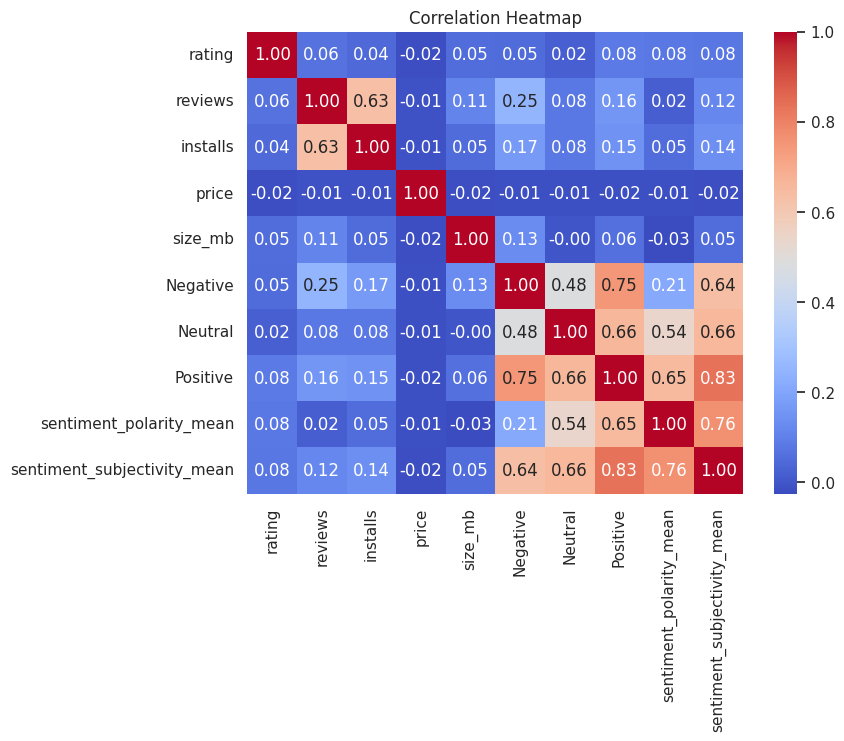

In [ ]:
# Chart - 18 Correlation Heatmap visualization code

plt.figure(figsize=(8,6))
# Select only numeric columns
corr = df_merged.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


##### 1. Why did you pick the specific chart?

A correlation heatmap is chosen to efficiently summarize relationships between multiple numerical and encoded categorical variables in a single visual. It allows quick assessment of which variables move together (positive/negative correlation) and the strength of these relationships, helping in initial feature selection, hypothesis formation, and decision making

##### 2. What is/are the insight(s) found from the chart?

*  The highest positive correlation is between **reviews and installs** (0.63), suggesting that more installs generally lead to more reviews, which is logical.

*  Sentiment variables ("Positive", "Neutral", "Negative", sentiment polarity/subjectivity) are moderately and strongly correlated with one another, showing consistency within sentiment scores.

*  The direct correlations between rating, size_mb, and price with installs are very weak (close to 0), indicating these features don't strongly affect the number of installs in isolation.

*  The lack of strong negative correlations suggests most variables are either independent or positively associated in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Business Insights:**
*  Businesses can focus on driving installs to increase reviews, which may improve their visibility or credibility in the app store.

**Negative Insights:**
*  No direct evidence from this heatmap points to negative growth.

#### Chart - 19 Pair-Plot

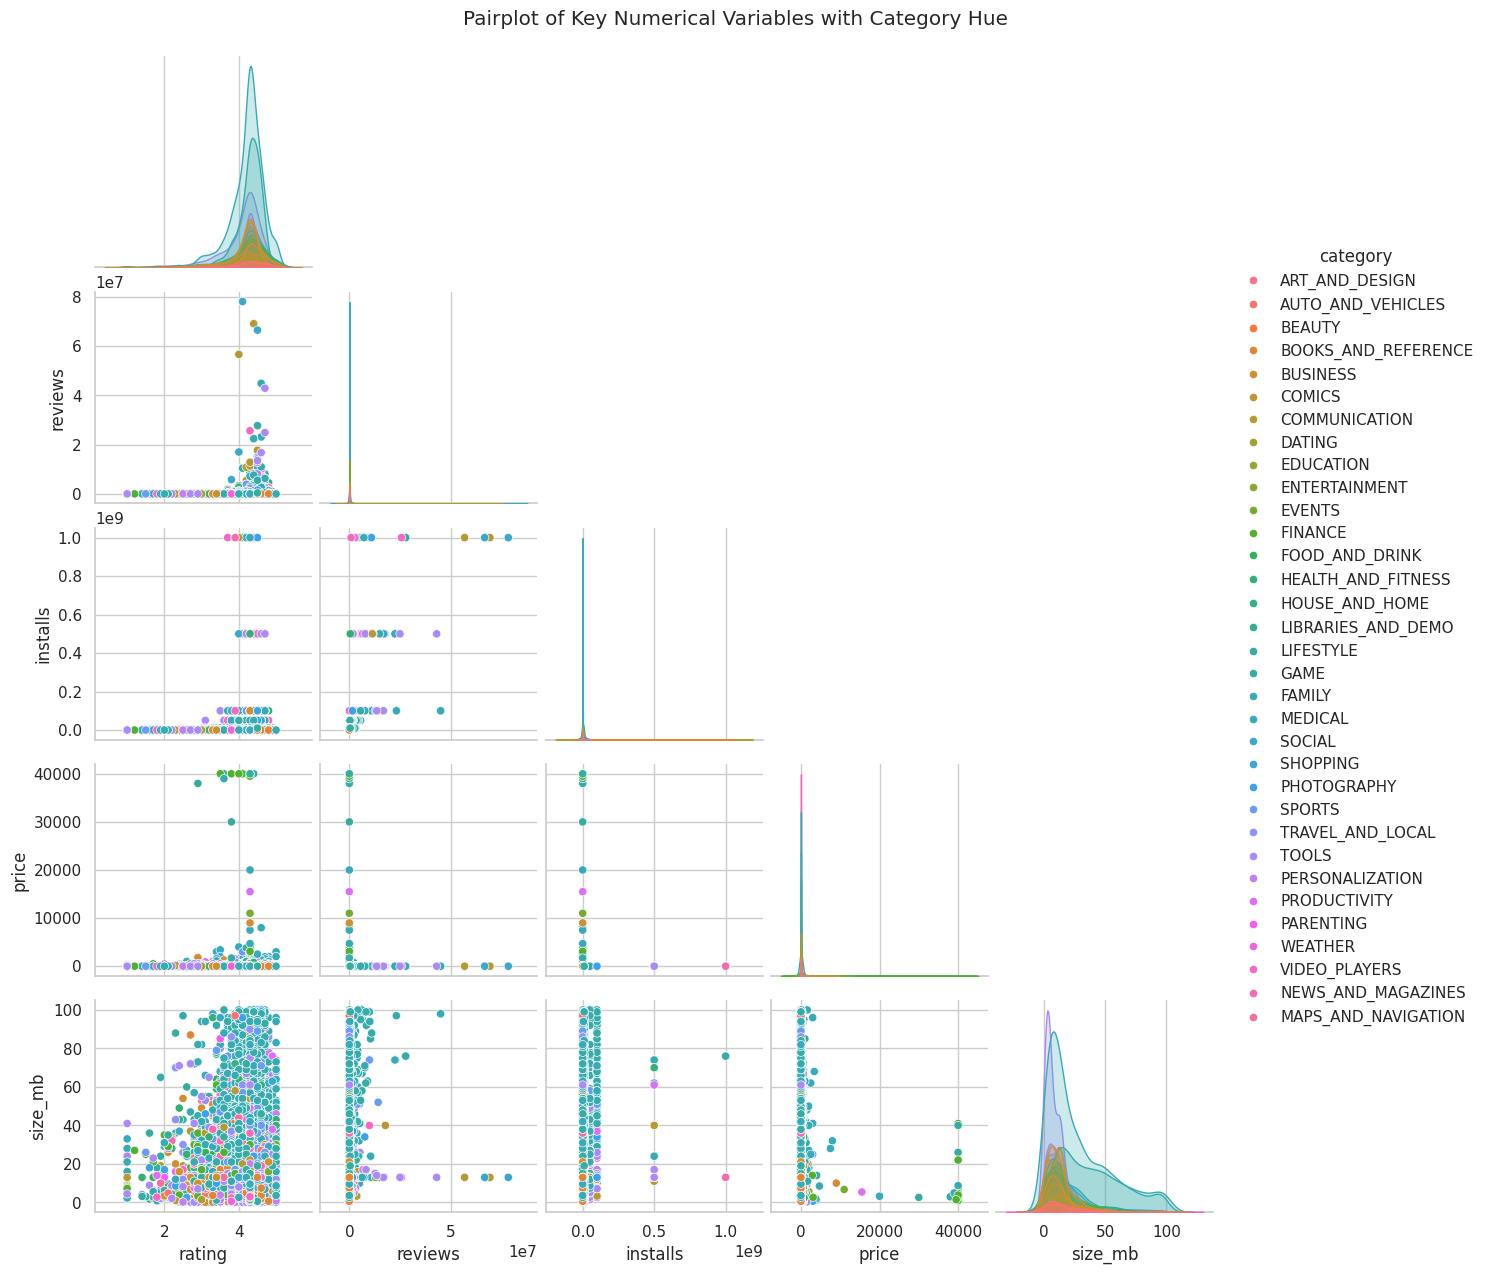

In [ ]:
# Chart - 19 PairPlot visulaization code

sns.pairplot(df_merged[['rating','reviews','installs','price','size_mb','category']],
             hue='category', diag_kind="kde", corner=True)
plt.suptitle("Pairplot of Key Numerical Variables with Category Hue", y=1.02)
plt.show()


##### 1. Why did you pick the specific chart?

Pairplot allows us to visualize relationships and correlations across multiple numerical variables simultaneously, helping spot trends, clusters, and outliers.

##### 2. What is/are the insight(s) found from the chart?

*  Strong positive correlation between Reviews and Installs.

*  Rating remains mostly stable across installs but a few low-rated apps have high installs.

*  Larger Size_MB apps don’t always guarantee higher installs.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

*  These insights can guide developers to focus on lightweight apps with good reviews, as they tend to attract more installs without sacrificing user ratings.

#### Chart - 20  Distribution of Ratings across Categories

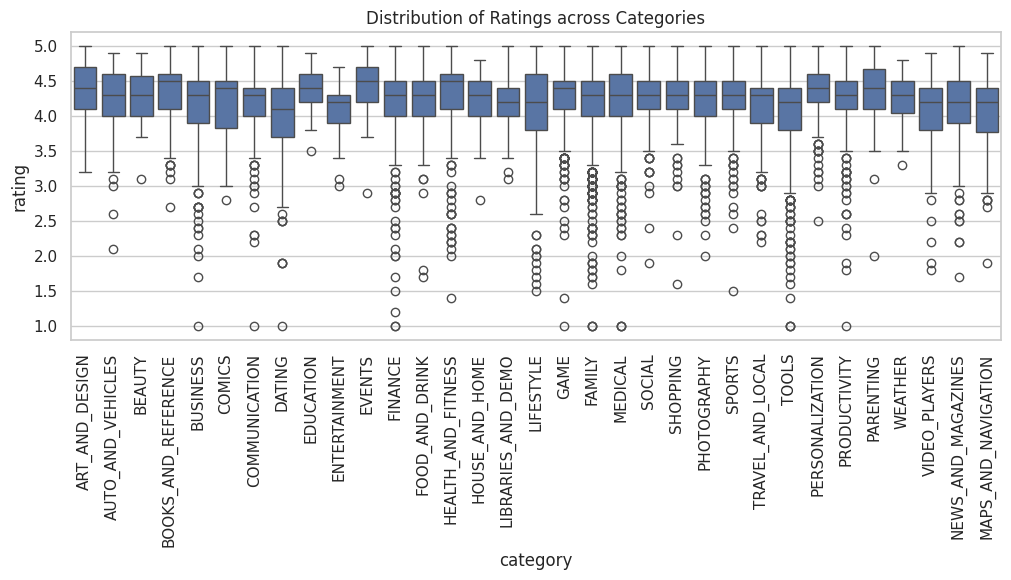

In [53]:
# Chart- 20 visualization code
plt.figure(figsize=(12,4))
sns.boxplot(data=df_merged, x="category", y="rating")
plt.xticks(rotation=90)
plt.title("Distribution of Ratings across Categories")
plt.show()


##### 1. Why did you pick the specific chart?

A boxplot is ideal to compare rating distributions across multiple categories and identify median, spread, and outliers in one view. It helps quickly understand variation and consistency in user ratings between app categories.

##### 2. What is/are the insight(s) found from the chart?

Most categories have high median ratings (around 4.0–4.5), indicating generally good user satisfaction. However, some categories show wider spread and many low-rating outliers, suggesting inconsistent app quality within those segments.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, categories with stable high ratings indicate strong user trust and potential areas for investment. Categories with many low-rating outliers may negatively impact growth, highlighting the need for quality improvement and stricter app standards.

#### Chart - 21 Reviews Distribution by App Category

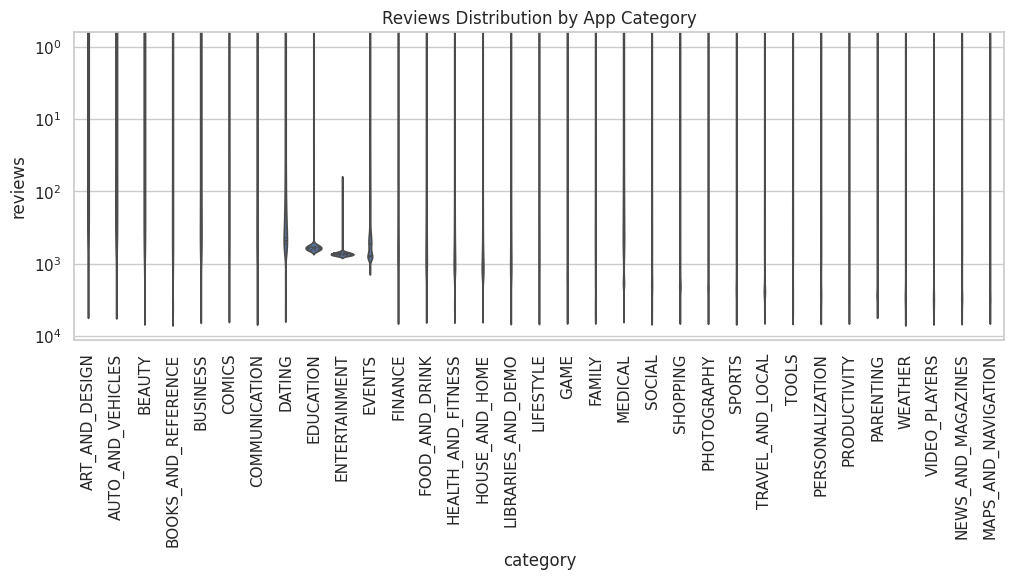

In [54]:
# Chart - 21 visualization code
plt.figure(figsize=(12,4))
sns.violinplot(data=df_merged, x="category", y="reviews", inner="quartile")
plt.xticks(rotation=90)
plt.yscale("log")  # reviews are usually skewed
plt.title("Reviews Distribution by App Category")
plt.show()


##### 1. Why did you pick the specific chart?

This chart helps compare the distribution of review counts across categories, especially when values vary widely. Using a log scale makes it easier to visualize categories with extremely high and low user engagement.

##### 2. What is/are the insight(s) found from the chart?

A few categories like Game, Social, and Communication show very high review volumes, indicating strong user engagement. Most other categories have significantly lower review counts, showing uneven user interaction across the Play Store.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, high-review categories indicate strong market demand and growth opportunities. Categories with low engagement may face slower growth, suggesting the need for better user acquisition strategies or feature improvements.

#### Chart - 22 Average Rating by Content Rating

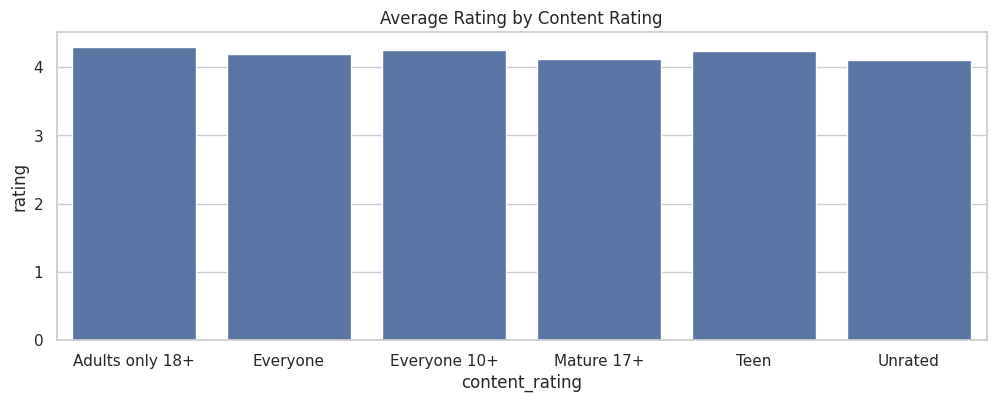

In [55]:
# Chart - 22 visualization code
plt.figure(figsize=(12,4))
avg_rating = df_merged.groupby("content_rating")["rating"].mean().reset_index()

sns.barplot(data=avg_rating, x="content_rating", y="rating")
plt.title("Average Rating by Content Rating")
plt.show()


##### 1. Why did you pick the specific chart?

A bar chart helps compare the average ratings across different content rating groups clearly. It makes it easy to identify which audience segment has higher or lower user satisfaction.

##### 2. What is/are the insight(s) found from the chart?

Average ratings are consistently high (around 4.1–4.3) across all content groups, showing overall good user satisfaction. Apps rated for Adults 18+ and Teen slightly outperform others, while Unrated and Mature 17+ show relatively lower averages.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, high-performing segments indicate strong user acceptance and potential growth areas. Lower-rated segments may negatively impact user trust, suggesting a need for quality improvement and better content moderation.

## **6. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

**Improved Business Objective Suggestion**

1. **Adopt a Freemium Model**

Since free apps generate significantly higher installs, the client should:

    *  Launch apps as free

    *  Monetize via ads or in-app purchases

    *  Avoid high upfront pricing

**Why?**

Paid apps show much lower user adoption.



---



2. **Focus on User Engagement & Reviews**

Analysis shows strong correlation (0.63) between reviews and installs.

Client should:

    *   Encourage users to rate and review

    *  Respond to feedback

    *  Improve features based on user complaints

    *  Run review campaigns inside the app

Impact: Higher visibility → more installs.



---



3. **Target a Broader Audience**

Apps rated Everyone/Teen have the highest installs.

My Recommendation:

    *  Avoid narrow audience targeting unless necessary

    *  Design for wider usability



---



4. **Optimize for Growth Categories**

Categories with highest installs:

    *  Game

    *  Social

    *  Communication

    *  Tools

Client should:

    *  Enter high-demand categories

    *  Or add features aligned with these use cases



---



5. **Keep App Size Optimized**

Most successful apps are: Under ~50 MB

Large apps may reduce downloads, especially in emerging markets.



---



6. **Compete on Quality, Not Just Features**

Ratings across Play Store are already high (~4+).

To stand out:

    *  Faster performance

    *  Bug-free experience

    *  Regular updates

# **Conclusion**

From the exploratory data analysis of the Google Play Store dataset, several key factors influencing app success were identified, validating most of the initial hypotheses.
---
*  **User engagement is the strongest driver of app success.**
 A strong positive relationship exists between the number of reviews and installs, indicating that higher user interaction significantly improves app visibility and growth.
---
*  **Free apps outperform paid apps in terms of installs.** The market is heavily dominated by free applications, suggesting that a freemium model is more effective for user acquisition than upfront pricing.
---
*  **App quality plays an important role in user adoption.** Apps with higher ratings tend to attract more installs, highlighting the importance of delivering a reliable and satisfying user experience.
---
*  **Category selection impacts app popularity.** Certain categories such as Games, Social, and Communication demonstrate significantly higher install volumes, indicating that choosing the right category can improve app visibility and reach.
---
*  **App success is highly skewed.** A small number of apps capture the majority of installs and reviews, while most apps struggle to gain significant traction in the competitive marketplace.
---
*  **Price and app size show relatively weak influence on installs.** While extremely high prices or very large app sizes may discourage some users, their overall impact is limited compared to factors such as app type (free vs paid) and user engagement.
---
**Overall, the analysis suggests that the most effective strategies for achieving long-term growth in the Google Play ecosystem include adopting a freemium approach, focusing on user engagement and feedback, maintaining high app quality, and strategically selecting high-demand categories.**
--